In [1]:
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

import numpy as np
import matplotlib.pyplot as plt
import orcs.process
import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt

import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

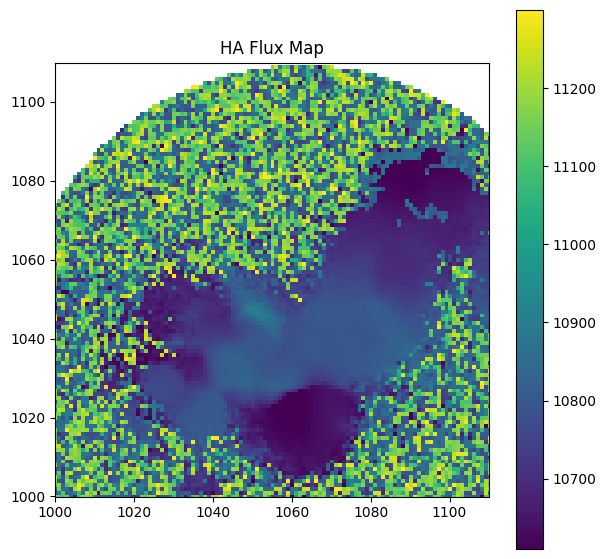

In [15]:
flux_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits') 
graph.imshow(flux_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("HA Flux Map")
pl.colorbar()
plt.savefig("/Users/leianydeoleo/Desktop/IIZw96/Halpha_SN3_map.png", dpi=300, bbox_inches="tight")

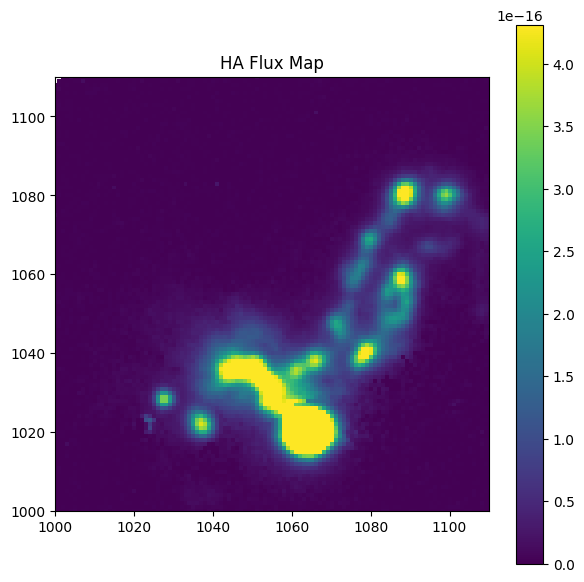

In [4]:
flux_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits') 
graph.imshow(flux_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("HA Flux Map")
pl.colorbar()

In [2]:
data_path = '/Users/leianydeoleo/Desktop/IIZw96/'

In [3]:
cube_SN3 = SpectralCube(data_path + 'SN3.hdf5')

deep_SN3 = cube_SN3.get_deep_frame()
deep_SN3_hdu = fits.open(data_path + 'deep_frame.fits')
wcs = WCS(deep_SN3_hdu[0].header)

xpix_bkgd, ypix_bkgd = 950, 950
# extract and plot a spectrum representative of the background around IIZw96
spectrum_background = cube_SN3.get_spectrum(xpix_bkgd, ypix_bkgd, 2) # option mean_flux

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


 [==========] [100%] [completed in 0.235 s]                                   


 [==========] [100%] [completed in 10.9 s]                                    


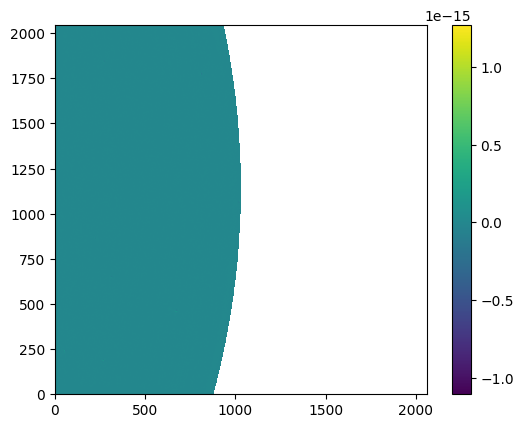

In [5]:
import matplotlib.pyplot as plt

plt.imshow(cube_SN3[:, :, 0], origin="lower", cmap="viridis")
plt.colorbar()
plt.show()

In [18]:
print(cube_SN3.dimx, cube_SN3.dimy, cube_SN3.dimz)

2048 2064 419


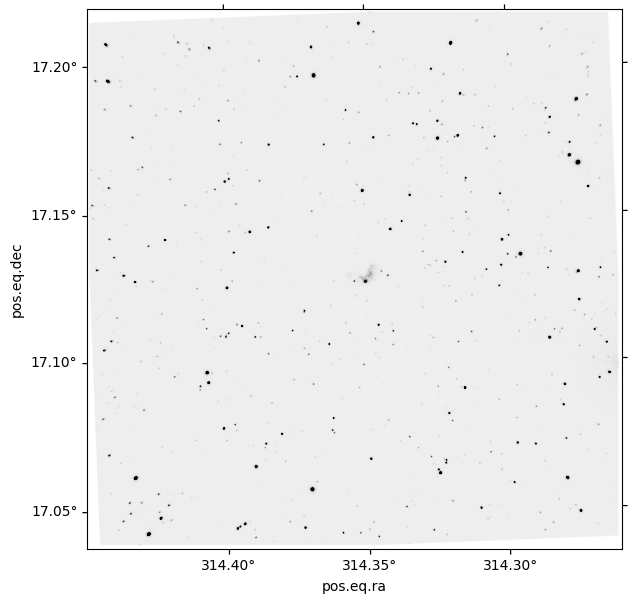

In [23]:
white = cube_SN3.get_deep_frame()
white.imshow(cmap='gray_r', perc=99.9)

In [15]:
data = cube_SN3.get_data(
    0, cube_SN3.dimx,
    0, cube_SN3.dimy,
    0, cube_SN3.dimz
)
image = np.nanmedian(data, axis=0)

 [==========] [100%] [completed in 1m32s]                                     


unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


KeyboardInterrupt



In [14]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.modeling import models, fitting
from regions import Regions

# =====================================================
# User input
# =====================================================

image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits"      # image to measure PSF
region_file = "/Users/leianydeoleo/Desktop/IIZW96/starSN3.reg"            # DS9 circular region

pixel_scale = 0.32      # arcsec/pixel

# =====================================================
# Read image
# =====================================================

image = fits.getdata(image_file)

# =====================================================
# Read DS9 region
# =====================================================

reg = Regions.read(region_file, format='ds9')[0]

xc = reg.center.x
yc = reg.center.y
r = reg.radius

# Convert to integers
xc = int(round(xc))
yc = int(round(yc))
r = int(np.ceil(r))

# =====================================================
# Extract cutout
# =====================================================

cutout = image[
    yc-r:yc+r+1,
    xc-r:xc+r+1
]

# =====================================================
# Coordinates
# =====================================================

yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# =====================================================
# Initial Gaussian
# =====================================================

g_init = models.Gaussian2D(
    amplitude=np.nanmax(cutout),
    x_mean=cutout.shape[1]/2,
    y_mean=cutout.shape[0]/2,
    x_stddev=2,
    y_stddev=2
)

fit = fitting.LevMarLSQFitter()

g = fit(g_init, xx, yy, cutout)

# =====================================================
# FWHM
# =====================================================

fwhm_x = 2.355 * g.x_stddev.value
fwhm_y = 2.355 * g.y_stddev.value

fwhm_pix = (fwhm_x + fwhm_y)/2
fwhm_arcsec = fwhm_pix * pixel_scale

print(f"FWHM X = {fwhm_x:.2f} pixels")
print(f"FWHM Y = {fwhm_y:.2f} pixels")
print(f"Mean FWHM = {fwhm_pix:.2f} pixels")
print(f"Spatial Resolution = {fwhm_arcsec:.2f} arcsec")

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(6,5))
plt.imshow(cutout, origin='lower', cmap='viridis')

plt.contour(
    g(xx,yy),
    colors='red',
    linewidths=1
)

plt.title(f"FWHM = {fwhm_arcsec:.2f}\"")
plt.colorbar(label='Counts')

plt.show()

ModuleNotFoundError: No module named 'regions'

In [22]:
from astropy.cosmology import Planck18

z = 0.03610

kpc_per_arcsec = Planck18.kpc_proper_per_arcmin(z).value / 60

print(kpc_per_arcsec)

0.7421115557744464


Center = (1343.66, 1569.89)
Radius = 9.65 pixels

========== Gaussian Fit ==========
Amplitude : 50999832.06
Sigma X   : 1.69 pix
Sigma Y   : 1.95 pix
FWHM X    : 3.97 pix
FWHM Y    : 4.58 pix
--------------------------------
Mean FWHM : 4.28 pixels
           1.368 arcsec
           1.013 kpc


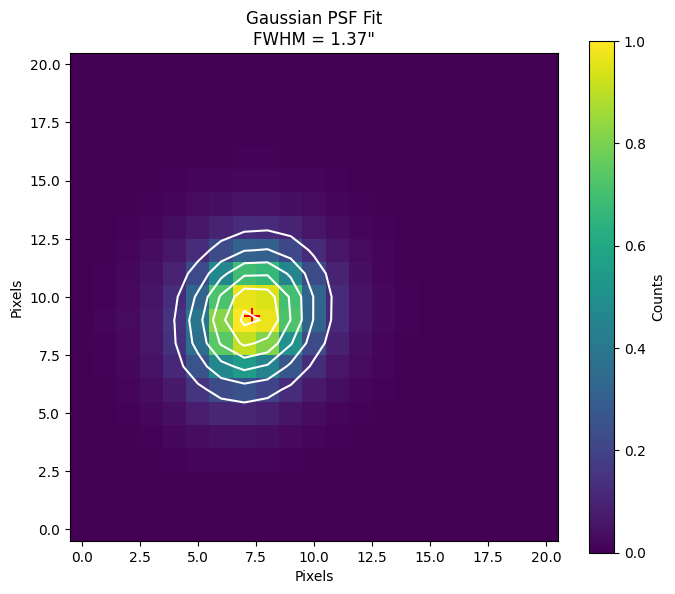

In [8]:
import re
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.modeling import models, fitting

# ==========================================================
# USER INPUT
# ==========================================================

image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits"
region_file = "/Users/leianydeoleo/Desktop/IIZW96/starSN3.reg"

pixel_scale = 0.32          # arcsec/pixel
kpc_per_arcsec = 0.74        # II Zw 96

# ==========================================================
# Read image
# ==========================================================

image = fits.getdata(image_file)

# ==========================================================
# Read DS9 region (circle)
# ==========================================================

with open(region_file) as f:
    text = f.read()

match = re.search(r'circle\(([^,]+),([^,]+),([^)]+)\)', text)

if match is None:
    raise ValueError("Region file does not contain a DS9 circle region.")

xc = float(match.group(1))
yc = float(match.group(2))
r = float(match.group(3))

print(f"Center = ({xc:.2f}, {yc:.2f})")
print(f"Radius = {r:.2f} pixels")

# convert to integers

xc_i = int(round(xc))
yc_i = int(round(yc))
r_i = int(np.ceil(r))

# ==========================================================
# Extract cutout
# ==========================================================

cutout = image[
    yc_i-r_i:yc_i+r_i+1,
    xc_i-r_i:xc_i+r_i+1
]

# ==========================================================
# Remove background
# ==========================================================

background = np.nanmedian(cutout)

cutout = cutout - background

cutout[cutout < 0] = 0

# ==========================================================
# Coordinates
# ==========================================================

yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# ==========================================================
# Initial Gaussian guess
# ==========================================================

g_init = models.Gaussian2D(
    amplitude=np.nanmax(cutout),
    x_mean=cutout.shape[1]/2,
    y_mean=cutout.shape[0]/2,
    x_stddev=2,
    y_stddev=2,
    theta=0
)

fit = fitting.LevMarLSQFitter()

g = fit(g_init, xx, yy, cutout)

# ==========================================================
# Compute FWHM
# ==========================================================

fwhm_x = 2.355 * abs(g.x_stddev.value)
fwhm_y = 2.355 * abs(g.y_stddev.value)

fwhm_pix = (fwhm_x + fwhm_y) / 2

fwhm_arcsec = fwhm_pix * pixel_scale

fwhm_kpc = fwhm_arcsec * kpc_per_arcsec

# ==========================================================
# Print results
# ==========================================================

print("\n========== Gaussian Fit ==========")

print(f"Amplitude : {g.amplitude.value:.2f}")

print(f"Sigma X   : {g.x_stddev.value:.2f} pix")
print(f"Sigma Y   : {g.y_stddev.value:.2f} pix")

print(f"FWHM X    : {fwhm_x:.2f} pix")
print(f"FWHM Y    : {fwhm_y:.2f} pix")

print("--------------------------------")

print(f"Mean FWHM : {fwhm_pix:.2f} pixels")
print(f"           {fwhm_arcsec:.3f} arcsec")
print(f"           {fwhm_kpc:.3f} kpc")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(7,6))

plt.imshow(cutout,
           origin='lower',
           cmap='viridis')

plt.contour(
    g(xx, yy),
    colors='white',
    linewidths=1.5
)

plt.scatter(g.x_mean.value,
            g.y_mean.value,
            marker='+',
            color='red',
            s=120)

plt.title(f"Gaussian PSF Fit\nFWHM = {fwhm_arcsec:.2f}\"")

plt.xlabel("Pixels")
plt.ylabel("Pixels")

plt.colorbar(label="Counts")

plt.tight_layout()
plt.show()

Center = (1343.66, 1569.90)
Radius = 1.00 pixels

========== Gaussian Fit ==========
Amplitude : 5987346.64
Sigma X   : 0.25 pix
Sigma Y   : 3.08 pix
FWHM X    : 0.59 pix
FWHM Y    : 7.26 pix
--------------------------------
Mean FWHM : 3.92 pixels
           1.255 arcsec
           0.929 kpc


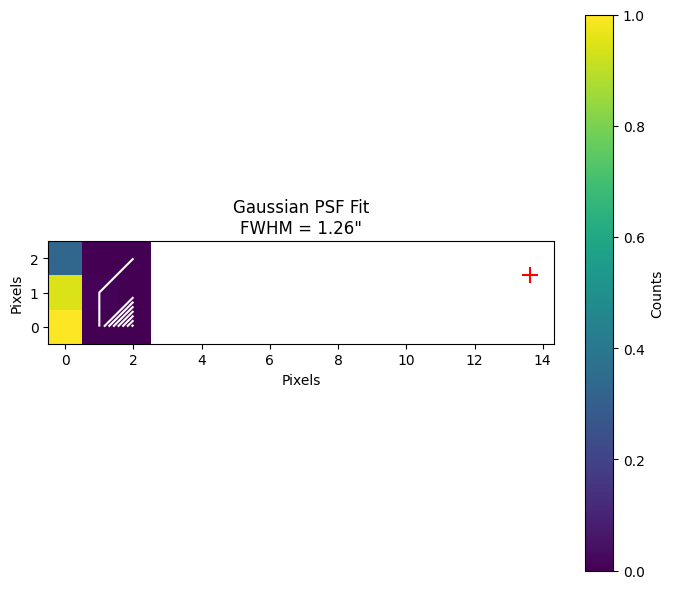

In [31]:
import re
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.modeling import models, fitting

# ==========================================================
# USER INPUT
# ==========================================================

image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits"
region_file = "/Users/leianydeoleo/Desktop/IIZW96/starSN3(1).reg"

pixel_scale = 0.32          # arcsec/pixel
kpc_per_arcsec = 0.74        # II Zw 96

# ==========================================================
# Read image
# ==========================================================

image = fits.getdata(image_file)

# ==========================================================
# Read DS9 region (circle)
# ==========================================================

with open(region_file) as f:
    text = f.read()

match = re.search(r'circle\(([^,]+),([^,]+),([^)]+)\)', text)

if match is None:
    raise ValueError("Region file does not contain a DS9 circle region.")

xc = float(match.group(1))
yc = float(match.group(2))
r = float(match.group(3))

print(f"Center = ({xc:.2f}, {yc:.2f})")
print(f"Radius = {r:.2f} pixels")

# convert to integers

xc_i = int(round(xc))
yc_i = int(round(yc))
r_i = int(np.ceil(r))

# ==========================================================
# Extract cutout
# ==========================================================

cutout = image[
    yc_i-r_i:yc_i+r_i+1,
    xc_i-r_i:xc_i+r_i+1
]

# ==========================================================
# Remove background
# ==========================================================

background = np.nanmedian(cutout)

cutout = cutout - background

cutout[cutout < 0] = 0

# ==========================================================
# Coordinates
# ==========================================================

yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# ==========================================================
# Initial Gaussian guess
# ==========================================================

g_init = models.Gaussian2D(
    amplitude=np.nanmax(cutout),
    x_mean=cutout.shape[1]/2,
    y_mean=cutout.shape[0]/2,
    x_stddev=2,
    y_stddev=2,
    theta=0
)

fit = fitting.LevMarLSQFitter()

g = fit(g_init, xx, yy, cutout)

# ==========================================================
# Compute FWHM
# ==========================================================

fwhm_x = 2.355 * abs(g.x_stddev.value)
fwhm_y = 2.355 * abs(g.y_stddev.value)

fwhm_pix = (fwhm_x + fwhm_y) / 2

fwhm_arcsec = fwhm_pix * pixel_scale

fwhm_kpc = fwhm_arcsec * kpc_per_arcsec

# ==========================================================
# Print results
# ==========================================================

print("\n========== Gaussian Fit ==========")

print(f"Amplitude : {g.amplitude.value:.2f}")

print(f"Sigma X   : {g.x_stddev.value:.2f} pix")
print(f"Sigma Y   : {g.y_stddev.value:.2f} pix")

print(f"FWHM X    : {fwhm_x:.2f} pix")
print(f"FWHM Y    : {fwhm_y:.2f} pix")

print("--------------------------------")

print(f"Mean FWHM : {fwhm_pix:.2f} pixels")
print(f"           {fwhm_arcsec:.3f} arcsec")
print(f"           {fwhm_kpc:.3f} kpc")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(7,6))

plt.imshow(cutout,
           origin='lower',
           cmap='viridis')

plt.contour(
    g(xx, yy),
    colors='white',
    linewidths=1.5
)

plt.scatter(g.x_mean.value,
            g.y_mean.value,
            marker='+',
            color='red',
            s=120)

plt.title(f"Gaussian PSF Fit\nFWHM = {fwhm_arcsec:.2f}\"")

plt.xlabel("Pixels")
plt.ylabel("Pixels")

plt.colorbar(label="Counts")

plt.tight_layout()
plt.show()

In [9]:
print(f"FWHM = {fwhm_arcsec:.2f} arcsec")

FWHM = 1.37 arcsec



========== MOFFAT FIT ==========
Amplitude : 52251494.51
Gamma     : 6.999 pixels
Alpha     : 8.370
--------------------------------
FWHM       : 4.11 pixels
Seeing     : 1.32 arcsec


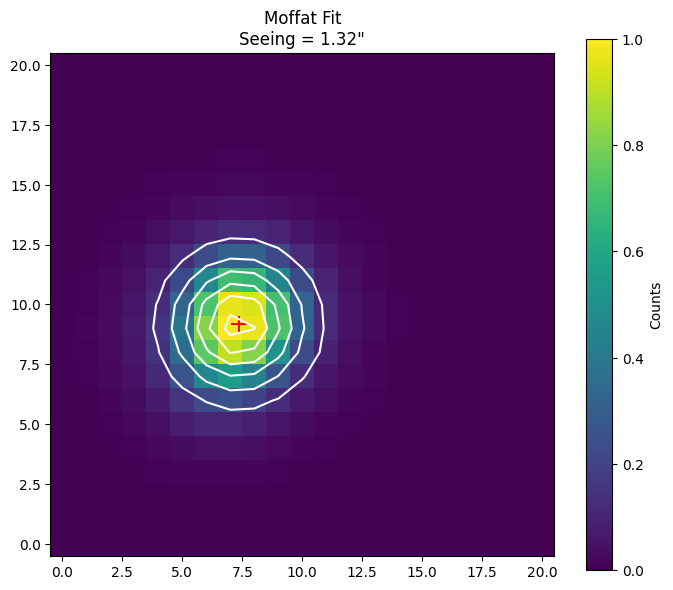

In [29]:
import re
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.modeling import models, fitting

# ==========================================================
# USER INPUT
# ==========================================================

image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits"
region_file = "/Users/leianydeoleo/Desktop/IIZW96/starSN3.reg"

pixel_scale = 0.32      # arcsec/pixel

# ==========================================================
# Read image
# ==========================================================

image = fits.getdata(image_file)

# ==========================================================
# Read DS9 circle region
# ==========================================================

with open(region_file) as f:
    text = f.read()

match = re.search(r'circle\(([^,]+),([^,]+),([^)]+)\)', text)

if match is None:
    raise ValueError("No circular region found.")

xc = float(match.group(1))
yc = float(match.group(2))
r = float(match.group(3))

xc = int(round(xc))
yc = int(round(yc))
r = int(np.ceil(r))

# ==========================================================
# Cutout
# ==========================================================

cutout = image[
    yc-r:yc+r+1,
    xc-r:xc+r+1
]

# ==========================================================
# Background subtraction
# ==========================================================

background = np.nanmedian(cutout)
cutout = cutout - background
cutout[cutout < 0] = 0

# ==========================================================
# Coordinates
# ==========================================================

yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# ==========================================================
# Initial Moffat model
# ==========================================================

m_init = models.Moffat2D(
    amplitude=np.nanmax(cutout),
    x_0=cutout.shape[1]/2,
    y_0=cutout.shape[0]/2,
    gamma=2.0,
    alpha=3.5
)

fit = fitting.LevMarLSQFitter()

m = fit(m_init, xx, yy, cutout)

# ==========================================================
# Compute FWHM
# ==========================================================

gamma = m.gamma.value
alpha = m.alpha.value

fwhm_pix = 2 * gamma * np.sqrt(2**(1/alpha) - 1)

fwhm_arcsec = fwhm_pix * pixel_scale

# ==========================================================
# Results
# ==========================================================

print("\n========== MOFFAT FIT ==========")

print(f"Amplitude : {m.amplitude.value:.2f}")
print(f"Gamma     : {gamma:.3f} pixels")
print(f"Alpha     : {alpha:.3f}")

print("--------------------------------")

print(f"FWHM       : {fwhm_pix:.2f} pixels")
print(f"Seeing     : {fwhm_arcsec:.2f} arcsec")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(7,6))

plt.imshow(cutout,
           origin='lower',
           cmap='viridis')

plt.contour(
    m(xx,yy),
    colors='white',
    linewidths=1.5
)

plt.scatter(m.x_0.value,
            m.y_0.value,
            marker='+',
            color='red',
            s=120)

plt.title(f"Moffat Fit\nSeeing = {fwhm_arcsec:.2f}\"")

plt.colorbar(label='Counts')

plt.tight_layout()

plt.show()


========== MOFFAT FIT ==========
Amplitude : 83889327776.29
Gamma     : 113.744 pixels
Alpha     : 6490.187
--------------------------------
FWHM       : 2.35 pixels
Seeing     : 0.75 arcsec


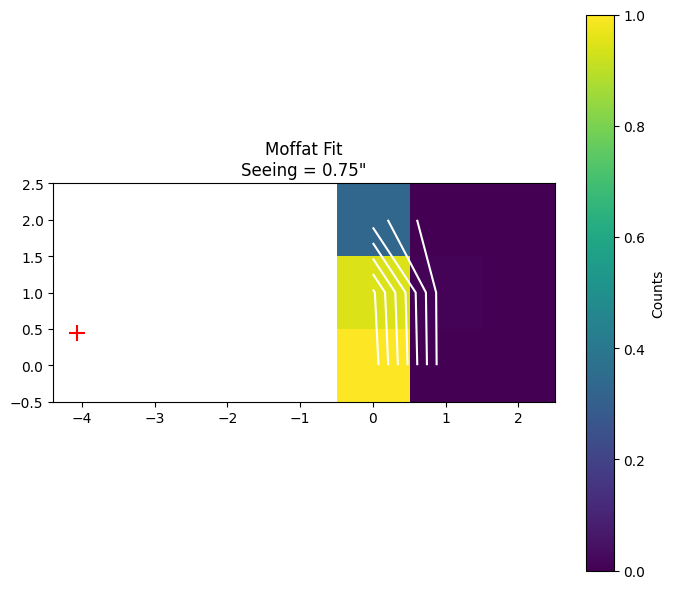

In [30]:
import re
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.modeling import models, fitting

# ==========================================================
# USER INPUT
# ==========================================================

image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits"
region_file = "/Users/leianydeoleo/Desktop/IIZW96/starSN3(1).reg"

pixel_scale = 0.32      # arcsec/pixel

# ==========================================================
# Read image
# ==========================================================

image = fits.getdata(image_file)

# ==========================================================
# Read DS9 circle region
# ==========================================================

with open(region_file) as f:
    text = f.read()

match = re.search(r'circle\(([^,]+),([^,]+),([^)]+)\)', text)

if match is None:
    raise ValueError("No circular region found.")

xc = float(match.group(1))
yc = float(match.group(2))
r = float(match.group(3))

xc = int(round(xc))
yc = int(round(yc))
r = int(np.ceil(r))

# ==========================================================
# Cutout
# ==========================================================

cutout = image[
    yc-r:yc+r+1,
    xc-r:xc+r+1
]

# ==========================================================
# Background subtraction
# ==========================================================

background = np.nanmedian(cutout)
cutout = cutout - background
cutout[cutout < 0] = 0

# ==========================================================
# Coordinates
# ==========================================================

yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# ==========================================================
# Initial Moffat model
# ==========================================================

m_init = models.Moffat2D(
    amplitude=np.nanmax(cutout),
    x_0=cutout.shape[1]/2,
    y_0=cutout.shape[0]/2,
    gamma=2.0,
    alpha=3.5
)

fit = fitting.LevMarLSQFitter()

m = fit(m_init, xx, yy, cutout)

# ==========================================================
# Compute FWHM
# ==========================================================

gamma = m.gamma.value
alpha = m.alpha.value

fwhm_pix = 2 * gamma * np.sqrt(2**(1/alpha) - 1)

fwhm_arcsec = fwhm_pix * pixel_scale

# ==========================================================
# Results
# ==========================================================

print("\n========== MOFFAT FIT ==========")

print(f"Amplitude : {m.amplitude.value:.2f}")
print(f"Gamma     : {gamma:.3f} pixels")
print(f"Alpha     : {alpha:.3f}")

print("--------------------------------")

print(f"FWHM       : {fwhm_pix:.2f} pixels")
print(f"Seeing     : {fwhm_arcsec:.2f} arcsec")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(7,6))

plt.imshow(cutout,
           origin='lower',
           cmap='viridis')

plt.contour(
    m(xx,yy),
    colors='white',
    linewidths=1.5
)

plt.scatter(m.x_0.value,
            m.y_0.value,
            marker='+',
            color='red',
            s=120)

plt.title(f"Moffat Fit\nSeeing = {fwhm_arcsec:.2f}\"")

plt.colorbar(label='Counts')

plt.tight_layout()

plt.show()

In [33]:
model = m(xx, yy)

residual = cutout - model

plt.figure(figsize=(5,5))
plt.imshow(residual, origin='lower', cmap='RdBu_r')
plt.colorbar(label='Residual')
plt.title("Data - Moffat Model")
plt.show()

ValueError: operands could not be broadcast together with shapes (21,21) (31,31) 

In [24]:
from astropy.io import fits
from astropy.stats import sigma_clipped_stats

from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources
from photutils.segmentation import SourceCatalog

import numpy as np

image = fits.getdata("/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits")

mean, median, std = sigma_clipped_stats(image)

finder = DAOStarFinder(
    threshold=8*std,
    fwhm=3.0
)

sources = finder(image-median)

print(len(sources))

1670


In [25]:
good = []

margin = 40

ny,nx = image.shape

for s in sources:

    x = s['xcentroid']
    y = s['ycentroid']

    if x<margin:
        continue

    if y<margin:
        continue

    if x>nx-margin:
        continue

    if y>ny-margin:
        continue

    if s['peak'] > 60000:
        continue

    good.append(s)

print(len(good))

369


In [26]:
from astropy.modeling import models,fitting

pixel_scale = 0.321

fit = fitting.LevMarLSQFitter()

results = []

In [27]:
for s in good:

    x = int(s['xcentroid'])
    y = int(s['ycentroid'])

    cut = image[y-15:y+16,x-15:x+16]

    if cut.shape!=(31,31):
        continue

    background = np.median(cut)

    cut = cut-background

    yy,xx=np.mgrid[:31,:31]

    model=models.Moffat2D(
        amplitude=cut.max(),
        x_0=15,
        y_0=15,
        gamma=2,
        alpha=3.5
    )

    try:

        m=fit(model,xx,yy,cut)

    except:

        continue

    gamma=m.gamma.value
    alpha=m.alpha.value

    fwhm_pix=2*gamma*np.sqrt(2**(1/alpha)-1)

    fwhm_arc=fwhm_pix*pixel_scale

    results.append({

        'x':x,
        'y':y,
        'fwhm_pix':fwhm_pix,
        'fwhm_arcsec':fwhm_arc

    })

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_60599/2482309952.py:36: RuntimeWarning: invalid value encountered in sqrt
  fwhm_pix=2*gamma*np.sqrt(2**(1/alpha)-1)



In [28]:
import pandas as pd

df=pd.DataFrame(results)

df.head()

,x,y,fwhm_pix,fwhm_arcsec
0,1794,40,37.787210,12.129695
1,1819,41,38.017142,12.203503
2,1845,42,38.011214,12.201600
3,1870,43,37.943320,12.179806
4,1895,44,38.023418,12.205517


In [20]:
median=df.fwhm_arcsec.median()

sigma=df.fwhm_arcsec.std()

df=df[
    np.abs(df.fwhm_arcsec-median)<2*sigma
]

In [21]:
print()

print("=================================")

print(f"Number of stars : {len(df)}")

print()

print(f"Mean seeing = {df.fwhm_arcsec.mean():.2f} arcsec")

print(f"Std         = {df.fwhm_arcsec.std():.2f} arcsec")


Number of stars : 294

Mean seeing = 1.07 arcsec
Std         = 0.47 arcsec


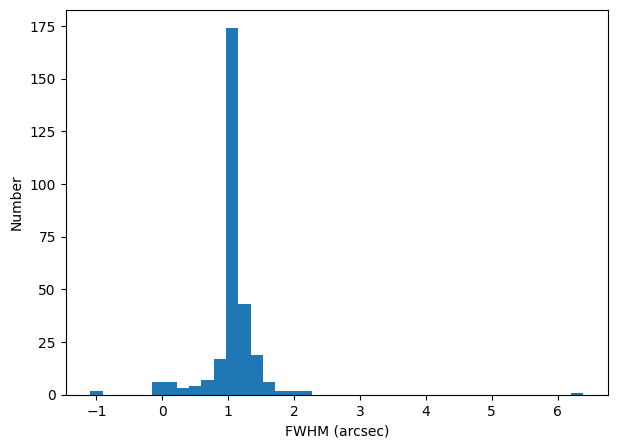

In [26]:
plt.figure(figsize=(7,5))

plt.hist(df.fwhm_arcsec, bins=40)

plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number")

plt.show()

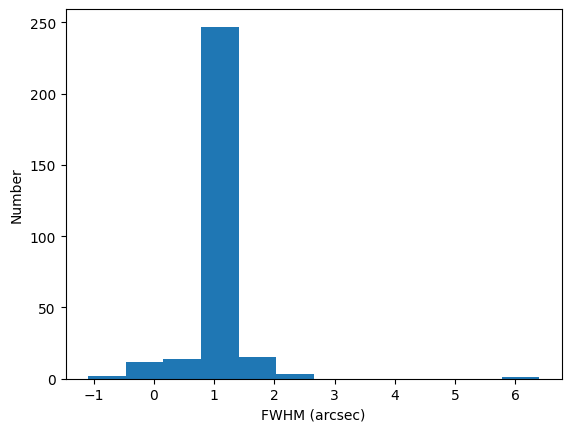

In [24]:
import matplotlib.pyplot as plt

plt.hist(df.fwhm_arcsec,bins=12)

plt.xlabel("FWHM (arcsec)")

plt.ylabel("Number")

plt.show()

In [27]:
from photutils.segmentation import detect_threshold
from photutils.segmentation import detect_sources
from photutils.segmentation import SourceCatalog

threshold = detect_threshold(image, nsigma=5)

segment_map = detect_sources(image, threshold, npixels=10)

catalog = SourceCatalog(image, segment_map)

table = catalog.to_table()

print(table.colnames)

['label', 'xcentroid', 'ycentroid', 'sky_centroid', 'bbox_xmin', 'bbox_xmax', 'bbox_ymin', 'bbox_ymax', 'area', 'semimajor_sigma', 'semiminor_sigma', 'orientation', 'eccentricity', 'min_value', 'max_value', 'local_background', 'segment_flux', 'segment_fluxerr', 'kron_flux', 'kron_fluxerr']


In [31]:
table = table[
    table["eccentricity"] < 0.20
]


table = table[
    table["max_value"] < 60000
]

from scipy.spatial import cKDTree
import numpy as np

xy = np.column_stack([
    table["xcentroid"],
    table["ycentroid"]
])

tree = cKDTree(xy)

dist, ind = tree.query(xy, k=2)

nearest = dist[:,1]

table = table[
    nearest > 12
]


    

In [7]:
from astropy.stats import sigma_clip

good = sigma_clip(
    df["fwhm_arcsec"],
    sigma=2.5,
    maxiters=5
)

df = df[~good.mask]

NameError: name 'df' is not defined

In [11]:
from photutils.segmentation import detect_threshold
from photutils.segmentation import detect_sources
from photutils.segmentation import SourceCatalog

image = fits.getdata("/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits")


threshold = detect_threshold(image, nsigma=5)

segment_map = detect_sources(image, threshold, npixels=10)

catalog = SourceCatalog(image, segment_map)

table = catalog.to_table()

table = table[
    table["eccentricity"] < 0.20
]

table = table[
    table["max_value"] < 60000
]

from scipy.spatial import cKDTree
import numpy as np

xy = np.column_stack([
    table["xcentroid"],
    table["ycentroid"]
])

tree = cKDTree(xy)

dist, ind = tree.query(xy, k=2)

nearest = dist[:,1]

table = table[
    nearest > 12
]

from astropy.stats import sigma_clip

good = sigma_clip(
    df["fwhm_arcsec"],
    sigma=2.5,
    maxiters=5
)

df = df[~good.mask]

print(f"Accepted stars : {len(df)}")

print(f"Mean seeing : {df.fwhm_arcsec.mean():.2f}\"")

print(f"Median seeing : {df.fwhm_arcsec.median():.2f}\"")

print(f"Std : {df.fwhm_arcsec.std():.2f}\"")

Accepted stars : 252
Mean seeing : 1.09"
Median seeing : 1.08"
Std : 0.12"


In [ ]:
from photutils.segmentation import detect_threshold
from photutils.segmentation import detect_sources
from photutils.segmentation import SourceCatalog

image = fits.getdata("/Users/leianydeoleo/Desktop/IIZW96/deep_frame.fits")


threshold = detect_threshold(image, nsigma=5)

segment_map = detect_sources(image, threshold, npixels=10)

catalog = SourceCatalog(image, segment_map)

table = catalog.to_table()

table = table[
    table["eccentricity"] < 0.20
]

table = table[
    table["max_value"] < 60000
]

from scipy.spatial import cKDTree
import numpy as np

xy = np.column_stack([
    table["xcentroid"],
    table["ycentroid"]
])

tree = cKDTree(xy)

dist, ind = tree.query(xy, k=2)

nearest = dist[:,1]

table = table[
    nearest > 12
]

from astropy.stats import sigma_clip

good = sigma_clip(
    df["fwhm_arcsec"],
    sigma=2.5,
    maxiters=5
)

df = df[~good.mask]

print(f"Accepted stars : {len(df)}")

print(f"Mean seeing : {df.fwhm_arcsec.mean():.2f}\"")

print(f"Median seeing : {df.fwhm_arcsec.median():.2f}\"")

print(f"Std : {df.fwhm_arcsec.std():.2f}\"")

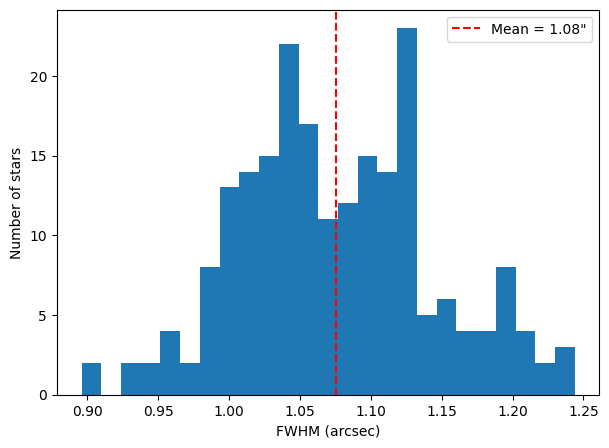

In [23]:
plt.figure(figsize=(7,5))
plt.hist(df["fwhm_arcsec"], bins=25)
plt.axvline(df["fwhm_arcsec"].mean(), color="r", ls="--",
            label=f"Mean = {df['fwhm_arcsec'].mean():.2f}\"")
plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.legend()
plt.show()

In [12]:
from astropy.stats import sigma_clip

good = sigma_clip(
    df["fwhm_arcsec"],
    sigma=2,
    maxiters=5
)

df_final = df[~good.mask]

print(df_final.fwhm_arcsec.mean())
print(df_final.fwhm_arcsec.std())
print(len(df_final))

1.065385418863792
0.04988200786125415
183


In [14]:
from astropy.stats import sigma_clip

good = sigma_clip(
    df["fwhm_arcsec"],
    sigma=2,
    maxiters=5
)

df_final = df[~good.mask]

print(df_final.fwhm_arcsec.mean())
print(df_final.fwhm_arcsec.std())
print(len(df_final))

1.065385418863792
0.04988200786125415
183


In [25]:
bad = df[
    (df.fwhm_arcsec < 0.9) |
    (df.fwhm_arcsec > 1.25)
]

print(bad)

       x     y  fwhm_pix  fwhm_arcsec
34   778   163  2.800701     0.899025
214  366  1202  2.791392     0.896037


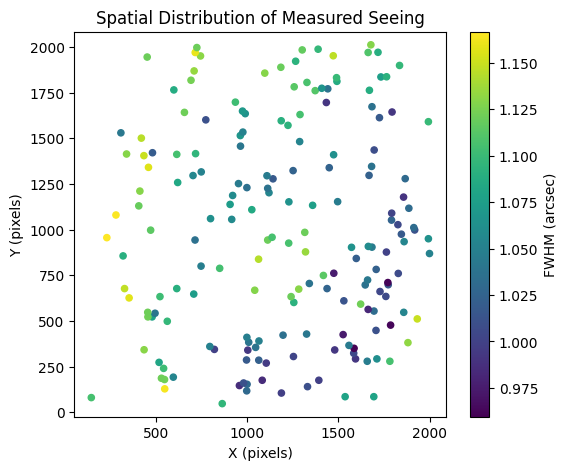

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(df_final["x"], df_final["y"],
            c=df_final["fwhm_arcsec"],
            cmap="viridis", s=20)

plt.colorbar(label="FWHM (arcsec)")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Spatial Distribution of Measured Seeing")
plt.axis("equal")
plt.show()

Text(0.5, 1.0, 'Accepted PSF Stars')

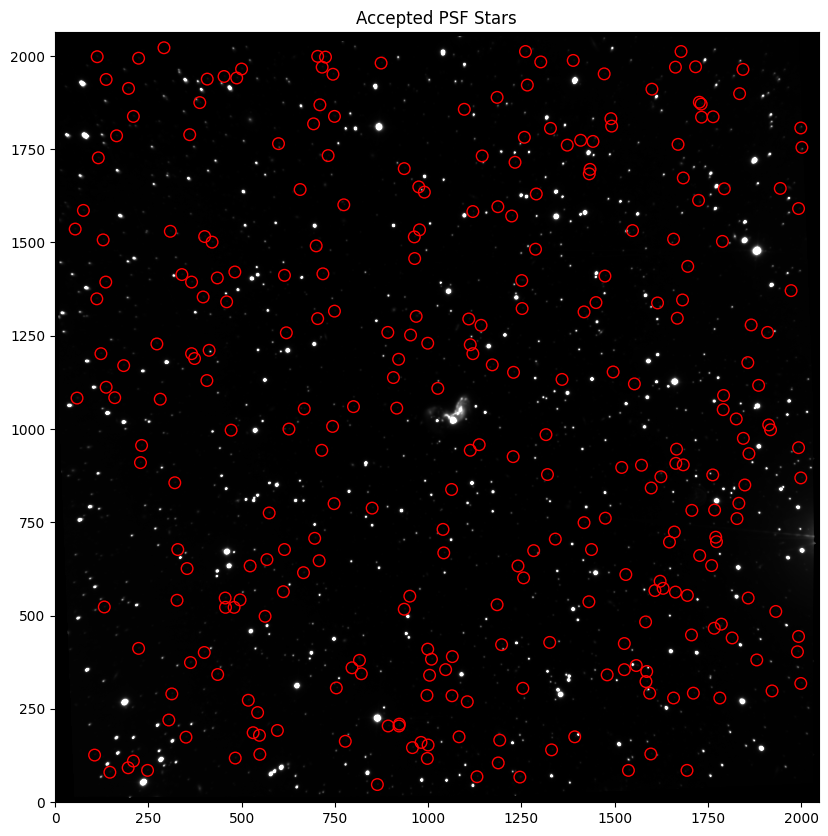

In [25]:
plt.figure(figsize=(10,10))

plt.imshow(
    image,
    origin='lower',
    cmap='gray',
    vmin=np.percentile(image,5),
    vmax=np.percentile(image,99.7)
)

plt.scatter(
    df.x,
    df.y,
    s=70,
    edgecolor='red',
    facecolor='none'
)

plt.title("Accepted PSF Stars")

In [5]:
x0 = 1344
y0 = 1570

data = cube_SN3.get_data(
    0, cube_SN3.dimx,
    0, cube_SN3.dimy,
    0, cube_SN3.dimz
)

 [==========] [100%] [completed in 1m14s]                                     


In [ ]:
image = np.nanmedian(data, axis=2)

cutout = image[y0-20:y0+21, x0-20:x0+21]

In [ ]:
import numpy as np
from astropy.modeling import models, fitting

y, x = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

g0 = models.Gaussian2D(
    amplitude=np.nanmax(cutout),
    x_mean=cutout.shape[1]/2,
    y_mean=cutout.shape[0]/2,
    x_stddev=2,
    y_stddev=2
)

In [ ]:
fitter = fitting.LevMarLSQFitter()
g = fitter(g0, x, y, cutout)

fwhm_x = 2.355 * g.x_stddev.value
fwhm_y = 2.355 * g.y_stddev.value

fwhm_pix = (fwhm_x + fwhm_y)/2

fwhm_arcsec = fwhm_pix * 0.32

print(f"Seeing = {fwhm_arcsec:.2f} arcsec")

In [6]:
import numpy as np
import astropy.units as u


# Load cube
cube = cube_SN3

# If needed, inspect/sanitize the spectral axis
spec = cube.spectral_axis

# Set the rest wavelength of H-alpha
halpha_rest = 6562.8 * u.AA


z = 0.03610  
halpha_obs = halpha_rest * (1 + z)

# Choose a line window around H-alpha
line_half_width = 12 * u.AA
line_min = halpha_obs - line_half_width
line_max = halpha_obs + line_half_width

# Choose continuum windows on both sides
cont1_min = halpha_obs - 35 * u.AA
cont1_max = halpha_obs - 20 * u.AA
cont2_min = halpha_obs + 20 * u.AA
cont2_max = halpha_obs + 35 * u.AA

# Extract subcubes
line_cube = cube.spectral_slab(line_min, line_max)
cont_cube_1 = cube.spectral_slab(cont1_min, cont1_max)
cont_cube_2 = cube.spectral_slab(cont2_min, cont2_max)

# Estimate continuum as average of sidebands
cont1 = cont_cube_1.median(axis=0)
cont2 = cont_cube_2.median(axis=0)
continuum = (cont1 + cont2) / 2

# Subtract continuum from each spectral channel in the line cube
line_cube_sub = line_cube - continuum

# Integrate along spectral axis to make moment 0 map
moment0 = line_cube_sub.moment(order=0)

# Save result
moment0.write("/Users/leianydeoleo/Desktop/halpha_moment0.fits", overwrite=True)

AttributeError: 'SpectralCube' object has no attribute 'spectral_axis'

In [7]:
import astropy.units as u

halpha_rest = 6562.8 * u.AA
z = 0.03610 
halpha_obs = halpha_rest * (1 + z)

line_cube = cube_SN3.spectral_slab(halpha_obs - 12*u.AA, halpha_obs + 12*u.AA)
cont1 = cube_SN3.spectral_slab(halpha_obs - 35*u.AA, halpha_obs - 20*u.AA).median(axis=0)
cont2 = cube_SN3.spectral_slab(halpha_obs + 20*u.AA, halpha_obs + 35*u.AA).median(axis=0)
continuum = (cont1 + cont2) / 2

moment0 = (line_cube - continuum).moment(order=0)
moment0.write("halpha_moment0.fits", overwrite=True)

AttributeError: 'SpectralCube' object has no attribute 'spectral_slab'

In [ ]:
from spectral_cube import SpectralCube
import astropy.units as u


subcube = cube_SN3.spectral_slab(6550*u.AA, 6575*u.AA)
moment0 = subcube.moment(order=0)
moment0.write('/Users/leianydeoleo/Desktop/IIZw96/moment0.fits')

In [4]:
con = 10e8 / 6563
print(con)

152369.34328813042


In [17]:
print('channel width (cm-1)', cube_SN3.params.base_axis[1] - cube_SN3.params.base_axis[0])
print('line width (cm-1)', cube_SN3.params.line_fwhm / 1.20671)
print('number of steps at the right of ZPD (contributing to the resolution)', cube_SN3.params.step_nb - cube_SN3.params.zpd_index)
print('ratio of the step number / the number of steps at the right of the ZPD', cube_SN3.params.step_nb / float(cube_SN3.params.step_nb - cube_SN3.params.zpd_index))
print('channel width (cm-1)', cube_SN3.params.line_fwhm / 1.20671 / 1.25)
print('Spectral resolution: ', cube_SN3.params.resolution)
mean_cm1 = (cube_SN3.params.base_axis[-1] + cube_SN3.params.base_axis[0]) / 2
print('Mean wavenumber', mean_cm1)
line_fwhm = mean_cm1 / cube_SN3.params.resolution
print('Line width (cm-1)',  line_fwhm)
print('channel width (cm-1)', line_fwhm / 1.20671 / 1.25)

channel width (cm-1) 4.206213201823629788
line width (cm-1) 5.324481364242122
number of steps at the right of ZPD (contributing to the resolution) 331
ratio of the step number / the number of steps at the right of the ZPD 1.2658610271903323
channel width (cm-1) 4.2595850913936975
Spectral resolution:  2331.546104697898
Mean wavenumber 14978.325211694301288
Line width (cm-1) 6.424202884735605749
channel width (cm-1) 4.2589870870287681506


 [==========] [100%] [completed in 0.020 s]                                   


unknown|WARNING| lines passed as float


velocity estimate (km/s) [10963.172804532578]
fluxes estimate (erg/cm^2/s) [[4.178144019241552e-17, 2.440948119631075e-16, 8.151745074042219e-17, 4.6474995827505e-17, 4.6474995827505e-17]]


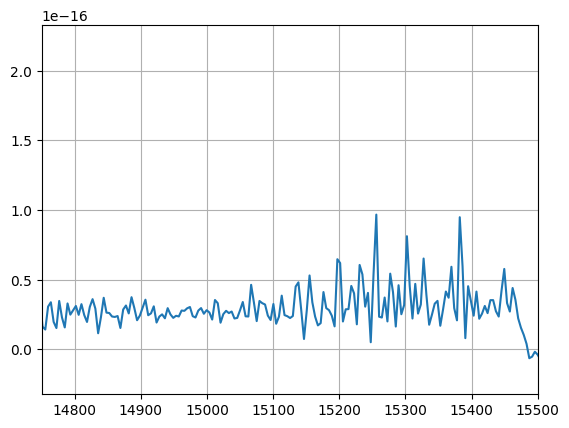

In [15]:
spec = cube_SN3.get_spectrum(1023.5, 1031.5, 3)
spec.plot()
pl.xlim((14750,15500))
pl.grid()

vel, fluxes = spec.estimate_parameters(('[NII]6548', 'Halpha', '[NII]6583', '[SII]6716', '[SII]6731'), [9000, 12000])
print('velocity estimate (km/s)', vel)
print('fluxes estimate (erg/cm^2/s)', fluxes)

=== Fit results ===
lines: ['[NII]6548', 'H3', '[NII]6584', '[SII]6717', '[SII]6731'], fmodel: sincgauss
iterations: 28, fit time: 3.16e-01 s
number of free parameters: 10, BIC: -1.55385e+04, chi2: 1.26e-06
Velocity (km/s): [11047.1(9.6) 10746.9(5.1) 11047.1(9.6) 11047.1(9.6) 11047.1(9.6)] 
Flux: [3e-33 +- 3.3e-17 6.29(64)e-16 2.09(33)e-16 2e-35 +- 1.7e-15
 2e-42 +- 1.8e-15]
Broadening (km/s): [0.97939252266642096(20) 47.9(7.4) 0.97939252266642096(20)
 0.97939252266642096(20) 0.97939252266642096(20)]
SNR (km/s): [9.11617297e-17 1.45756993e+01 6.35949244e+00 1.04218580e-20
 8.47393992e-28]

(11047.111327266588, 10746.941548872283)


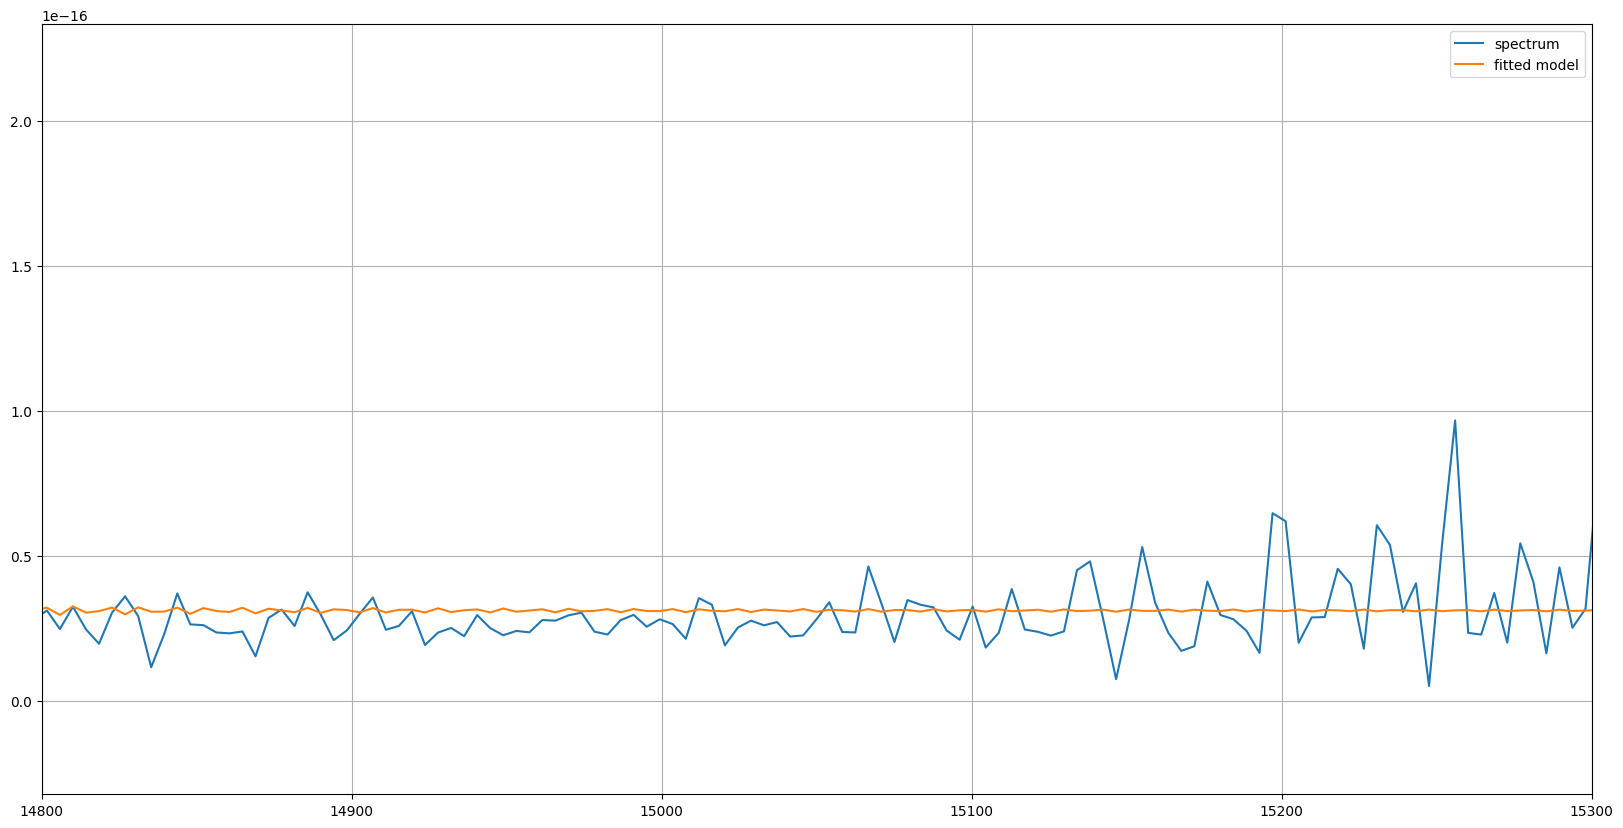

In [11]:

fit = spec.fit(('[NII]6548', 'Halpha', '[NII]6583', '[SII]6716', '[SII]6731'),
                   fmodel='sincgauss',
                   pos_def=['1','2','1','1','1'],
                   pos_cov=[vel, vel],
                   sigma_def=['1','2','1','1','1'],
                   sigma_cov=[20, 20],
                   nofilter=True)

print(fit)
new_vel = fit['velocity'][0], fit['velocity'][1]
print(new_vel)

pl.figure(figsize=(20,10))
spec.plot(label='spectrum')
fit.get_spectrum().plot(label='fitted model')
pl.xlim((14800,15300))
pl.legend()
pl.grid()

In [19]:
new_vel = 89 # km/s
fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','1','1'],
pos_cov = [10860],
sigma_def=['1','1','1'],
sigma_cov = [20],
amp_def=['1', '2', '1'],
amp_guess=[1, 1, amp_ratio],
nofilter=True, binning=1)

unknown|INFO| creating output file for 20 parameters x 3 lines (1.01449728 Go)
unknown|INFO|  > allocating: height
unknown|INFO|  > allocating: height-err
unknown|INFO|  > allocating: amplitude
unknown|INFO|  > allocating: amplitude-err
unknown|INFO|  > allocating: velocity
unknown|INFO|  > allocating: velocity-err
unknown|INFO|  > allocating: fwhm
unknown|INFO|  > allocating: fwhm-err
unknown|INFO|  > allocating: sigma
unknown|INFO|  > allocating: sigma-err
unknown|INFO|  > allocating: flux
unknown|INFO|  > allocating: flux-err
unknown|INFO|  > allocating: logGBF
unknown|INFO|  > allocating: chi2
unknown|INFO|  > allocating: rchi2
unknown|INFO|  > allocating: ks_pvalue
unknown|INFO|  > allocating: cont_p0
unknown|INFO|  > allocating: cont_p1
unknown|INFO|  > allocating: cont_p2
unknown|INFO|  > allocating: cont_p3
unknown|INFO| Number of spectra to fit: 25579
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py:166: RuntimeWarning: invalid value encounte

 [==========] [100%] [completed in 0.058 s]                                   


unknown|INFO| fitting started at 2026-06-11 20:26:02.009546
unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : []
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|INFO| 180 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [          ] [4%] [nans/pix|nanh] [20.2 s|15.7 s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [          ] [5%] [3.39s/pix|3.01h] [2h5m6s|27m59s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [          ] [5%] [3.07s/pix|2.72h] [2h23m7s|28m49s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particu

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [========  ] [82%] [2.27s/pix|2.02h] 52s|22m21s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3

unknown|INFO| Closing parallel processing server
unknown|INFO| Writing height maps
unknown|WARNING| param height is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height.fits in 0.17 s 
unknown|INFO| Writing height-err maps
unknown|WARNING| param height-err is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height-err.fits in 0.12 s 
unknown|INFO| Writing amplitude maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude.fits in 0.09 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.amplitude.fits in 0.14 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.amplitude.fits in 0.09 s 
unknown|INFO| Writing amplitude-err maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude-err.fits in 0.12 s 
unknown|INFO| Data written as ./IIZw96_SN3/

In [38]:
new_vel = 89 # km/s
fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','2','2'],
pos_cov = [10690,10690],
sigma_def=['1','2','2'],
sigma_cov = [20,20],
amp_def=['1', '2', '1'],
amp_guess=[1, 1, amp_ratio],
nofilter=True, binning=1)

unknown|INFO| creating output file for 20 parameters x 3 lines (1.01449728 Go)
unknown|INFO|  > allocating: height
unknown|INFO|  > allocating: height-err
unknown|INFO|  > allocating: amplitude
unknown|INFO|  > allocating: amplitude-err
unknown|INFO|  > allocating: velocity
unknown|INFO|  > allocating: velocity-err
unknown|INFO|  > allocating: fwhm
unknown|INFO|  > allocating: fwhm-err
unknown|INFO|  > allocating: sigma
unknown|INFO|  > allocating: sigma-err
unknown|INFO|  > allocating: flux
unknown|INFO|  > allocating: flux-err
unknown|INFO|  > allocating: logGBF
unknown|INFO|  > allocating: chi2
unknown|INFO|  > allocating: rchi2
unknown|INFO|  > allocating: ks_pvalue
unknown|INFO|  > allocating: cont_p0
unknown|INFO|  > allocating: cont_p1
unknown|INFO|  > allocating: cont_p2
unknown|INFO|  > allocating: cont_p3
unknown|INFO| Number of spectra to fit: 25579
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py:166: RuntimeWarning: invalid value encounte

 [==========] [100%] [completed in 0.024 s]                                   

unknown|INFO| fitting started at 2026-06-12 17:45:06.597168


unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : []
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|INFO| 180 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [          ] [4%] [nans/pix|nanh] [9.3 s|6.7 s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [          ] [5%] [1.93s/pix|1.71h] [1h11m9s|15m53s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [          ] [5%] [1.82s/pix|1.61h] [1h50m57s|22m16s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particu

...

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [========  ] [83%] [2.50s/pix|2.22h] 28s|23m13s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [========  ] [83%] [2.50s/pix|2.22h] 39s|22m22s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider regist

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [========  ] [88%] [2.50s/pix|2.22h] 9s|15m42s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [========  ] [89%] [2.50s/pix|2.22h] 57s|14m51s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registe

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 870, in curve_fit
    res = least_squares(func, p0, ja

unknown|INFO| Closing parallel processing server


unknown|INFO| Writing height maps
unknown|WARNING| param height is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height.fits in 0.15 s 
unknown|INFO| Writing height-err maps
unknown|WARNING| param height-err is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height-err.fits in 0.09 s 
unknown|INFO| Writing amplitude maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude.fits in 0.06 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.amplitude.fits in 0.06 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.amplitude.fits in 0.08 s 
unknown|INFO| Writing amplitude-err maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude-err.fits in 0.06 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.amplitude-e

In [50]:
#start new fitting (try sigma 20 first then 15)
new_vel = 80 # km/s
fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','1','1'],
pos_cov = [10660],
sigma_def=['1','1','1'],
sigma_cov = [20],
#amp_def=['1', '2', '1'],
#amp_guess=[1, 1, amp_ratio],
nofilter=True, binning=1)

unknown|INFO| creating output file for 20 parameters x 3 lines (1.01449728 Go)
unknown|INFO|  > allocating: height
unknown|INFO|  > allocating: height-err
unknown|INFO|  > allocating: amplitude
unknown|INFO|  > allocating: amplitude-err
unknown|INFO|  > allocating: velocity
unknown|INFO|  > allocating: velocity-err
unknown|INFO|  > allocating: fwhm
unknown|INFO|  > allocating: fwhm-err
unknown|INFO|  > allocating: sigma
unknown|INFO|  > allocating: sigma-err
unknown|INFO|  > allocating: flux
unknown|INFO|  > allocating: flux-err
unknown|INFO|  > allocating: logGBF
unknown|INFO|  > allocating: chi2
unknown|INFO|  > allocating: rchi2
unknown|INFO|  > allocating: ks_pvalue
unknown|INFO|  > allocating: cont_p0
unknown|INFO|  > allocating: cont_p1
unknown|INFO|  > allocating: cont_p2
unknown|INFO|  > allocating: cont_p3
unknown|INFO| Number of spectra to fit: 25579
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py:166: RuntimeWarning: invalid value encounte

 [==========] [100%] [completed in 0.107 s]                                   


unknown|INFO| fitting started at 2026-06-12 22:14:42.296242
unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : []
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|INFO| 180 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [          ] [4%] [nans/pix|nanh] [26.7 s|20.0 s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [          ] [5%] [3.89s/pix|3.45h] [2h23m16s|32m4s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
 [          ] [5%] [3.58s/pix|3.18h] [2h50m52s|34m26s]In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and parti

unknown|INFO| Closing parallel processing server


unknown|INFO| Writing height maps
unknown|WARNING| param height is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height.fits in 0.09 s 
unknown|INFO| Writing height-err maps
unknown|WARNING| param height-err is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height-err.fits in 0.04 s 
unknown|INFO| Writing amplitude maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude.fits in 0.02 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.amplitude.fits in 0.03 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.amplitude.fits in 0.05 s 
unknown|INFO| Writing amplitude-err maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude-err.fits in 0.03 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.amplitude-e

In [14]:
#final fit 
new_vel = 80 # km/s
fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','1','1'],
pos_cov = [10660],
sigma_def=['1','1','1'],
sigma_cov = [15],
#amp_def=['1', '2', '1'],
#amp_guess=[1, 1, amp_ratio],
nofilter=True, binning=1)

unknown|INFO| creating output file for 20 parameters x 3 lines (1.01449728 Go)
unknown|INFO|  > allocating: height
unknown|INFO|  > allocating: height-err
unknown|INFO|  > allocating: amplitude
unknown|INFO|  > allocating: amplitude-err
unknown|INFO|  > allocating: velocity
unknown|INFO|  > allocating: velocity-err
unknown|INFO|  > allocating: fwhm
unknown|INFO|  > allocating: fwhm-err
unknown|INFO|  > allocating: sigma
unknown|INFO|  > allocating: sigma-err
unknown|INFO|  > allocating: flux
unknown|INFO|  > allocating: flux-err
unknown|INFO|  > allocating: logGBF
unknown|INFO|  > allocating: chi2
unknown|INFO|  > allocating: rchi2
unknown|INFO|  > allocating: ks_pvalue
unknown|INFO|  > allocating: cont_p0
unknown|INFO|  > allocating: cont_p1
unknown|INFO|  > allocating: cont_p2
unknown|INFO|  > allocating: cont_p3
unknown|INFO| Number of spectra to fit: 25579
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py:166: RuntimeWarning: invalid value encounte

 [==========] [100%] [completed in 0.021 s]                                   


unknown|INFO| fitting started at 2026-06-30 19:17:00.674822
unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : []
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|INFO| 180 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [=         ] [12%] [1.43s/pix|1.27h] 52s|26m15s]Status messages could not be retrieved
 [==        ] [25%] [1.32s/pix|1.17h] 0s|33m37s]Status messages could not be retrieved
 [==        ] [28%] [1.28s/pix|1.13h] [1h13m5s|33m47s]Status messages could not be retrieved
 [==========] [100%] [1.64s/pix|1.46h] [0.000 s|0.000 s]Status messages could not be retrieved
 [==========] [100%] [completed in 2h13m4s]                                   

unknown|INFO| Closing parallel processing server


unknown|INFO| Writing height maps
unknown|WARNING| param height is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height.fits in 1.66 s 
unknown|INFO| Writing height-err maps
unknown|WARNING| param height-err is the same for all lines
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.height-err.fits in 1.64 s 
unknown|INFO| Writing amplitude maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude.fits in 1.55 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.amplitude.fits in 1.57 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.amplitude.fits in 1.73 s 
unknown|INFO| Writing amplitude-err maps
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.amplitude-err.fits in 1.46 s 
unknown|INFO| Data written as ./IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.amplitude-e

In [5]:
spectrum = cube_SN3.get_spectrum(1023.5, 1031.5, 3)

 [==========] [100%] [completed in 0.022 s]                                   


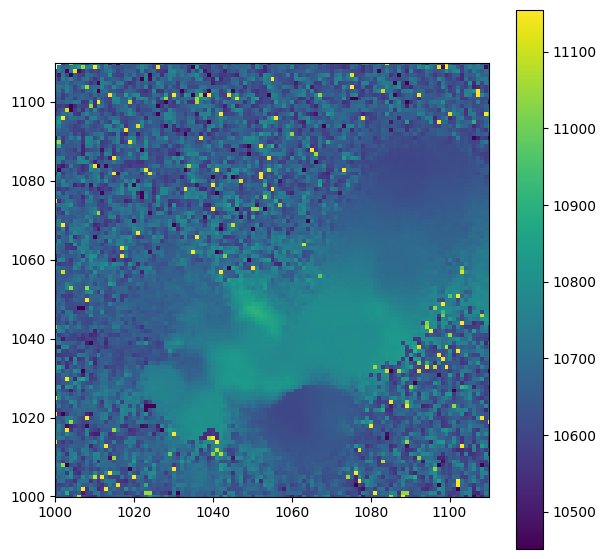

In [5]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/MAPS(sigma 20)/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()
#velocity=10690,sigma=20

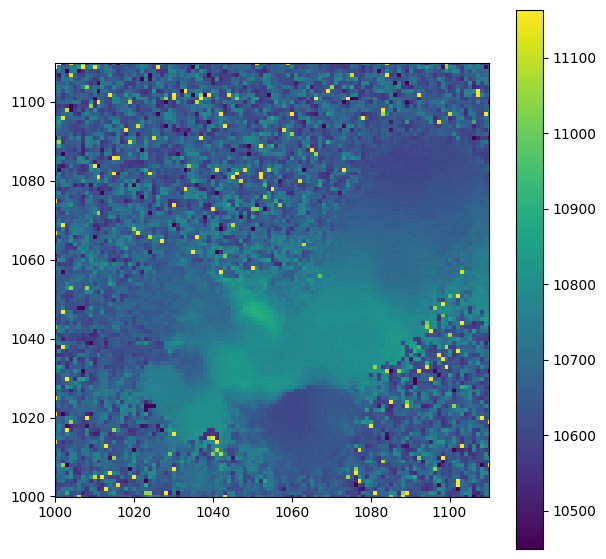

In [6]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()
#velocity=10660,sigma=15

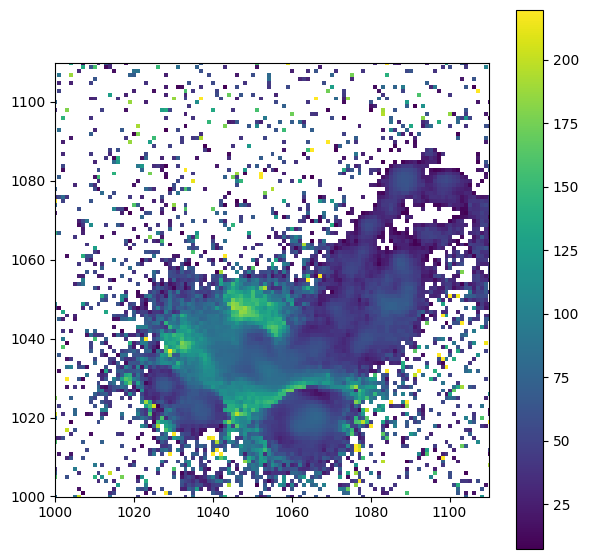

In [7]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/IIZW96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()
#velocity=10690,sigma=20

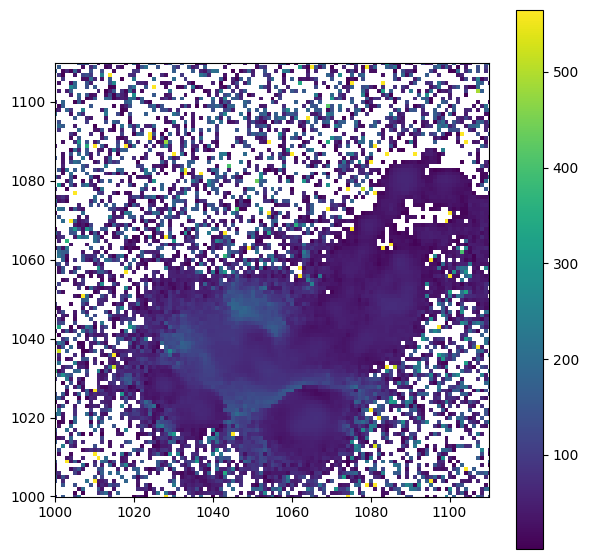

In [8]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/MAPS(sigma 20)/IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()
#velocity=10690,sigma=20

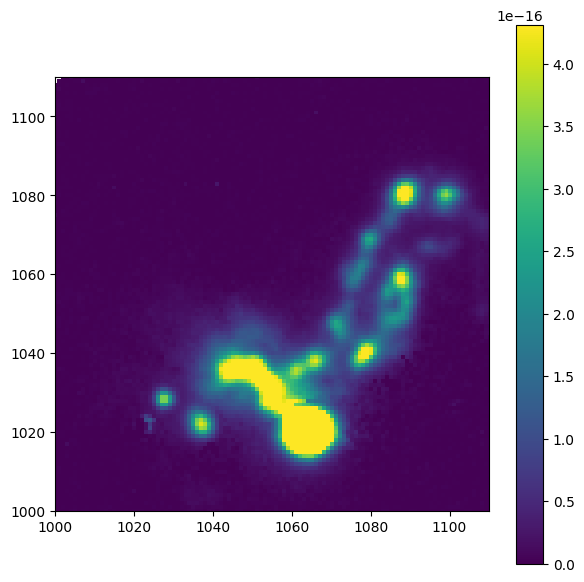

In [9]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()
#velocity=10690,sigma=20

In [ ]:
flux_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.flux.fits') 
graph.imshow(flux_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("[NII6548] Flux Map")
pl.colorbar()
#plt.savefig("/Users/leianydeoleo/Desktop/IIZw96/NII6548_SN3_map.png", dpi=300, bbox_inches="tight")

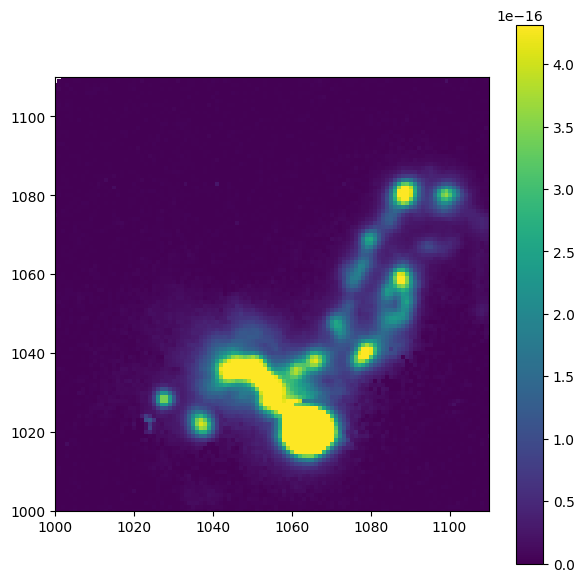

In [9]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/MAPS(sigma 20)/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()
#velocity=10690,sigma=20

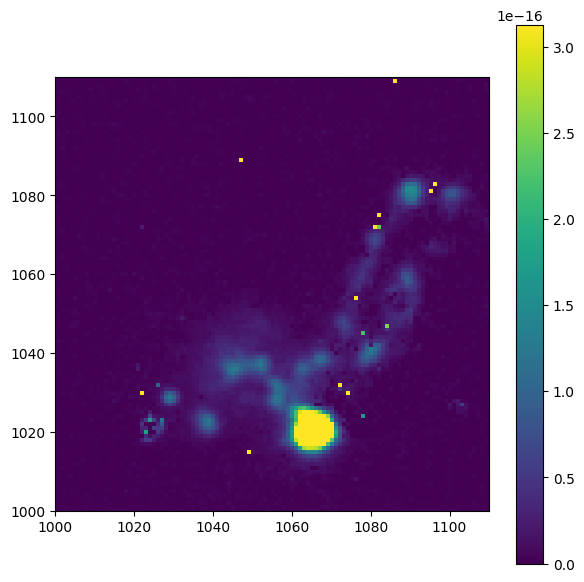

In [8]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()
#velocity=10690,sigma=20

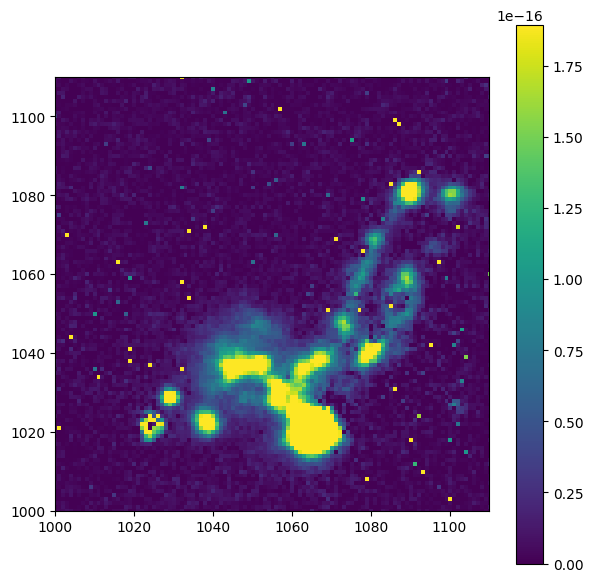

In [16]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.4959.1x1.flux.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()

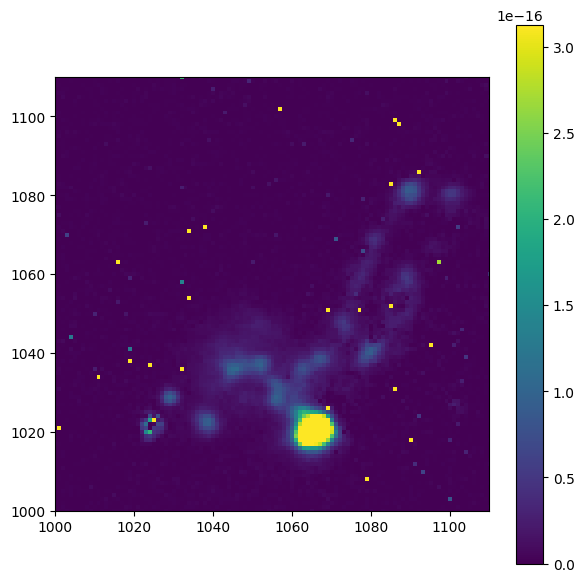

In [17]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN2/MAPS/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits') 
graph.imshow(vel_map)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
pl.colorbar()

 [==========] [100%] [completed in 0.026 s]                                   
=== Fit results ===
lines: ['H3', '[NII]6584', '[NII]6548'], fmodel: sincgauss
iterations: 23, fit time: 1.87e-01 s
number of free parameters: 10, BIC: -1.55194e+04, chi2: 1.39e-06
Velocity (km/s): [10746.2(5.6) 10774(22) 10774(22)] 
Flux: [6.37(69)e-16 9.1(3.5)e-17 2.6(3.4)e-17]
Broadening (km/s): [50.6(7.6) 0.715065225808375(18) 0.715065225808375(18)]
SNR (km/s): [13.67769886  2.63461189  0.77960941]



(14600.0, 14800.0)

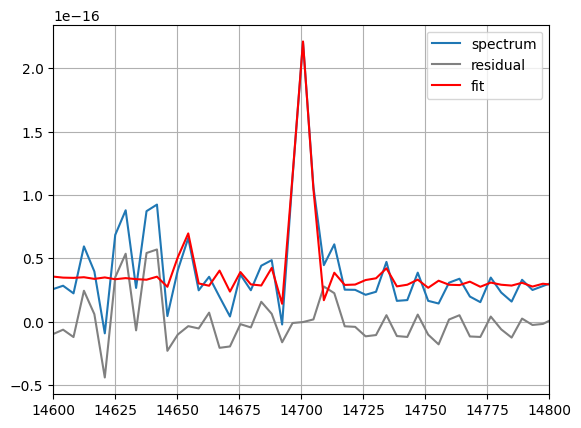

In [85]:
spec = cube_SN3.get_spectrum(1023.5, 1031.5, 3)
fit = spec.fit(
    ['Halpha', '[NII]6583','[NII]6548' ],
    fmodel='sincgauss',
    pos_cov=(10650,10650),
    pos_def=['1', '2','2'],
    sigma_def=['1', '2','2'],
    sigma_cov=(40,40),
    nofilter=True,
    poly_order=2)
print(fit)
spec.plot(label='spectrum')
fit.plot_residual(label='residual', c='gray') # plot the residual of the fit
fit.plot(label='fit', c='red') # plot the fitted vector

plt.grid()
plt.legend()
plt.xlim(14600,14800)

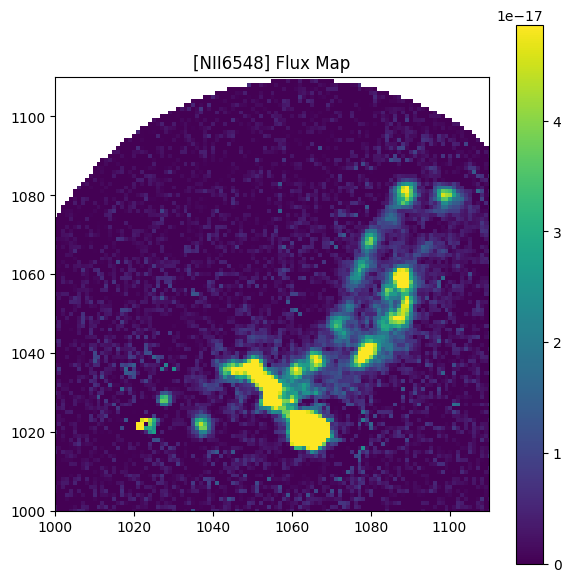

In [23]:
flux_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6548.1x1.flux.fits') 
graph.imshow(flux_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("[NII6548] Flux Map")
pl.colorbar()
plt.savefig("/Users/leianydeoleo/Desktop/IIZw96/NII6548_SN3_map.png", dpi=300, bbox_inches="tight")

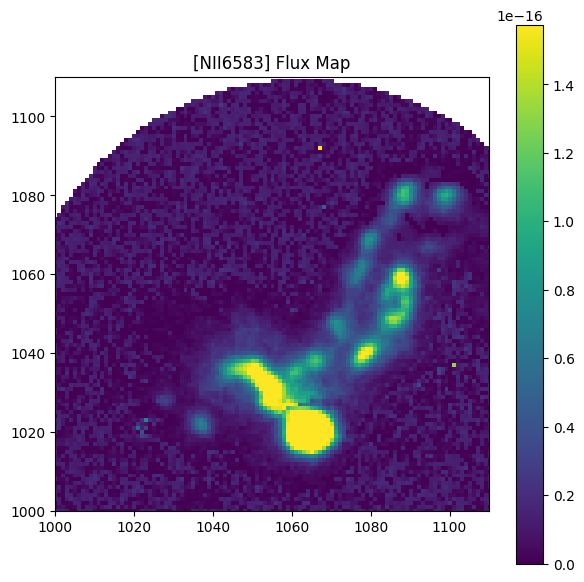

In [20]:
flux_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits') 
graph.imshow(flux_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("[NII6583] Flux Map")
pl.colorbar()
plt.savefig("/Users/leianydeoleo/Desktop/IIZw96/NII6583_SN3_map.png", dpi=300, bbox_inches="tight")

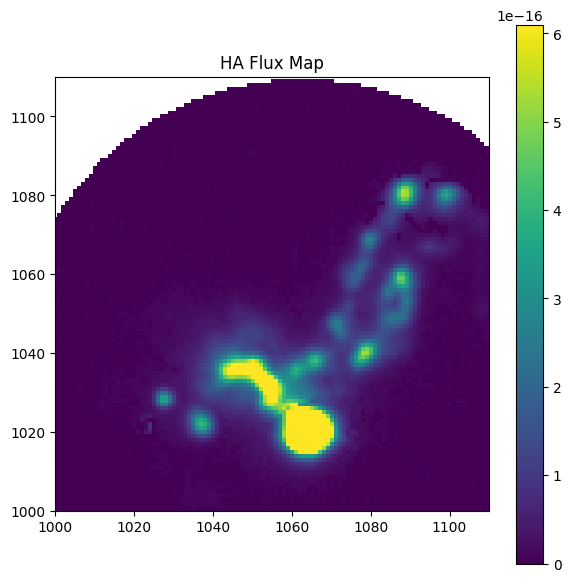

In [25]:
flux_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits') 
graph.imshow(flux_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("HA Flux Map")
pl.colorbar()
plt.savefig("/Users/leianydeoleo/Desktop/IIZw96/Halpha_SN3_map.png", dpi=300, bbox_inches="tight")

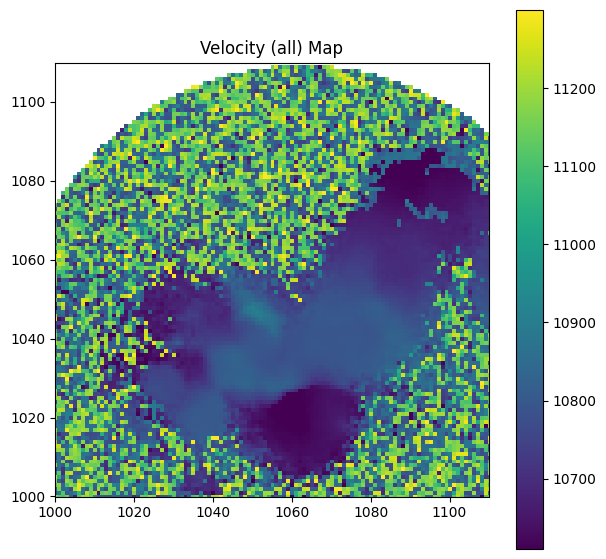

In [46]:
velocity_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits') 
graph.imshow(velocity_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("Velocity (all) Map")
pl.colorbar()

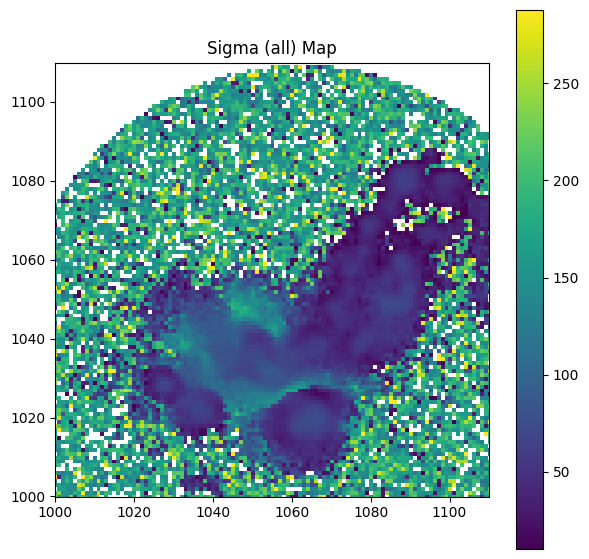

In [45]:
sigma_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits') 
graph.imshow(sigma_map_SN3)
pl.xlim(1000, 1110)
pl.ylim(1000, 1110)
plt.title("Sigma (all) Map")
pl.colorbar()
plt.savefig("/Users/leianydeoleo/Desktop/IIZw96/sigma(all)_SN3_map.png", dpi=300, bbox_inches="tight")

In [5]:
amp_ratio = cube_SN3.get_amp_ratio_from_flux_ratio('[NII]6583', '[NII]6548', 2.92)

In [6]:
vel, sigma = spectrum.estimate_parameters(('[NII]6548', 'Halpha', '[NII]6583'),)
print('velocity estimate (km/s)', vel)
print('sigma estimate (erg/cm^2/s)', sigma)

unknown|WARNING| lines passed as float


velocity estimate (km/s) [-1276.5072765072764]
sigma estimate (erg/cm^2/s) [[4.708944725790735e-17, 6.735287674901469e-17, 8.695098464281948e-17]]


In [22]:
estimates = cube_SN3.estimate_parameters_in_region(data_path +'SN2_Region.reg', ('[NII]6548', 'Halpha', '[NII]6583' ), [-6000, 12000],
                                               binning=1,threshold=0)

 [==========] [100%] [completed in 0.068 s]                                   


unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : []
unknown|INFO| 188 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [          ] [6%] [1.79s/pix|1.72h] 30s|22m46s]Status messages could not be retrieved
 [======    ] [62%] [0.93s/pix|0.90h] 39s|20m5s]                          

Process ForkServerPoolWorker-716:
Process ForkServerPoolWorker-392:
Process ForkServerPoolWorker-397:
Process ForkServerPoolWorker-391:
Process ForkServerPoolWorker-400:
Process ForkServerPoolWorker-395:
Process ForkServerPoolWorker-402:
Process ForkServerPoolWorker-389:
Process ForkServerPoolWorker-393:
Process ForkServerPoolWorker-390:
Process ForkServerPoolWorker-398:
Process ForkServerPoolWorker-396:
Process ForkServerPoolWorker-403:
Process ForkServerPoolWorker-401:
Process ForkServerPoolWorker-399:
Process ForkServerPoolWorker-404:
Process ForkServerPoolWorker-394:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
  

<function SpectralCube.process_by_pixel.<locals>.process_in_row at 0x10f09bf40>: Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/parallel.py", line 35, in run_dill_encoded
    return fun(*args)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py", line 545, in process_in_row
    out_row.append(_func(irow_data[i,:], *iargs_list))
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/fit.py", line 863, in estimate_parameters_in_pixel
    res = orb.utils.fit.estimate_velocity_prepared(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/fit.py", line 205, in estimate_velocity_prepared
    imat = np.nansum(mat * combs[i][1][:,filter_range_pix[0]:filter_range_pix[1]], axis=1)
  File "<__array_function__ internals>", line 200, in nansum
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py", line 722, in nansum
    a, mask = _replace_nan(a, 0)
 

KeyboardInterrupt: 

)
KeyboardInterrupt
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 365, in get
    res = self._reader.recv_bytes()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/connection.py", line 414, in _recv_bytes
    buf = self._recv(4)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/connection.py", line 379, in _recv
    chunk = read(handle, remaining)
KeyboardInterrupt
Traceback (most recent call last):
  File "/opt/anaconda3/en

 File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py", line 107, in _replace_nan
    a = np.array(a, subok=True, copy=True)
KeyboardInterrupt

<function SpectralCube.process_by_pixel.<locals>.process_in_row at 0x10f09bf40>: Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/parallel.py", line 35, in run_dill_encoded
    return fun(*args)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py", line 545, in process_in_row
    out_row.append(_func(irow_data[i,:], *iargs_list))
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/fit.py", line 863, in estimate_parameters_in_pixel
    res = orb.utils.fit.estimate_velocity_prepared(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/fit.py", line 205, in estimate_velocity_prepared
    imat = np.nansum(mat * combs[i][1][:,filter_range_pix[0]:filter_range_pix[1]], axis=1)
  File "<__array_function__ 

vs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker


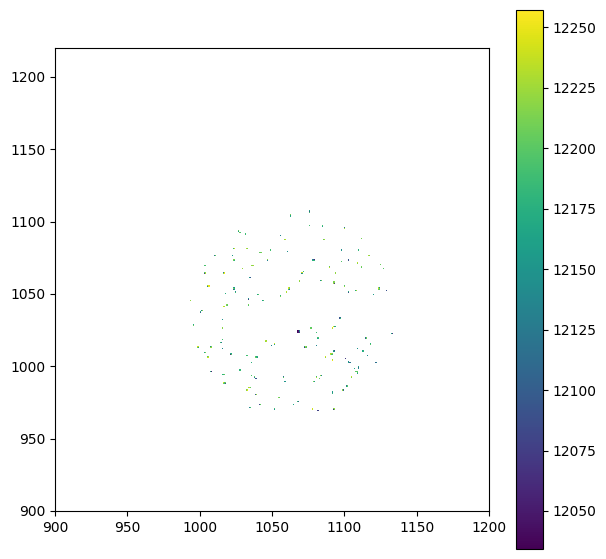

In [21]:
import orb.utils.graph as graph
estimate_vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZw96_SN3/Estimated_1x1/IIZw96_SN3.SpectralCube.estimated_velocity.0.fits')
graph.imshow(estimate_vel_map)
pl.xlim(900, 1200)
pl.ylim(900, 1220)
pl.colorbar()

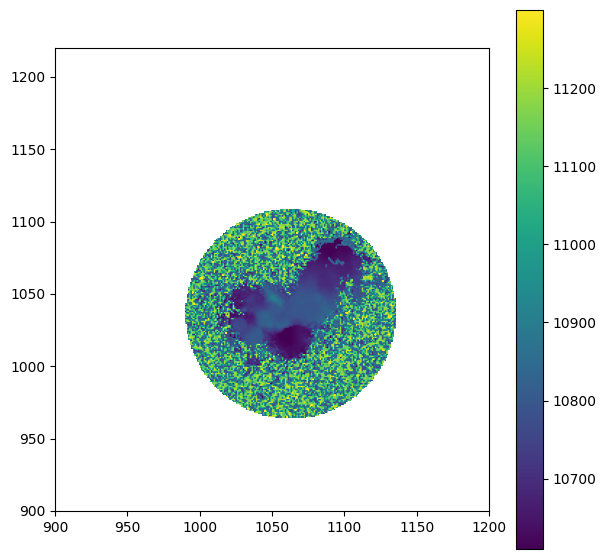

In [23]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits')
graph.imshow(vel_map)
pl.xlim(900, 1200)
pl.ylim(900, 1220)
pl.colorbar()

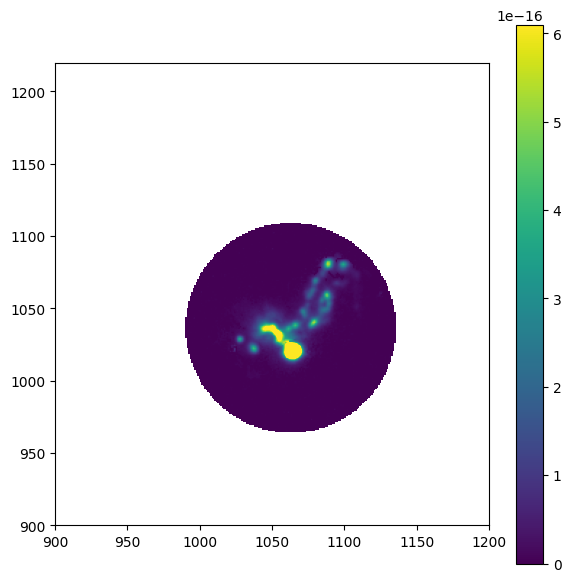

In [29]:
vel_map = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
graph.imshow(vel_map)
pl.xlim(900, 1200)
pl.ylim(900, 1220)
pl.colorbar()

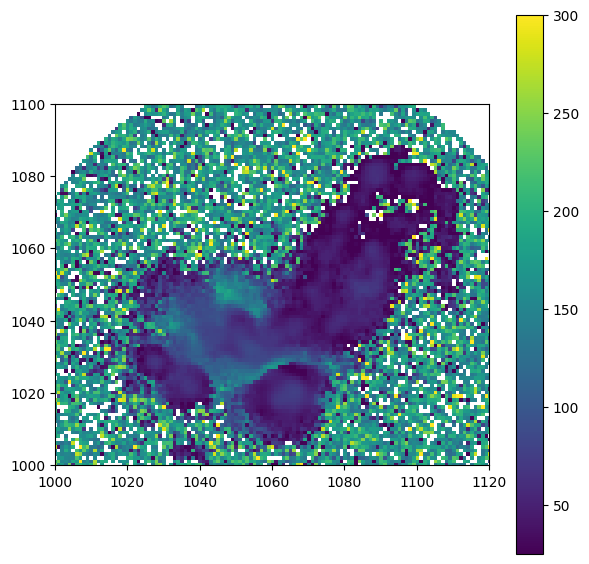

In [77]:
sigma_map = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits')
graph.imshow(sigma_map)
pl.xlim(1000, 1120)
pl.ylim(1000, 1100)
pl.colorbar()
pl.clim(25,300)

In [50]:
estimates = cube_SN3.estimate_parameters_in_region(data_path +'SN2_Region.reg', ('[NII]6548', 'Halpha', '[NII]6583' ), [10700, 10800],
                                               binning=1,threshold=0)

 [==========] [100%] [completed in 0.018 s]                                   


unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : []
unknown|INFO| 166 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [==========] [100%] [completed in 7m23s]                                     

unknown|INFO| Closing parallel processing server


unknown|INFO| Data written as ./IIZw96_SN3/Estimated_1x1/IIZw96_SN3.SpectralCube.estimated_velocity.0.fits in 0.33 s 
unknown|INFO| Data written as ./IIZw96_SN3/Estimated_1x1/IIZw96_SN3.SpectralCube.estimated_score.0.fits in 0.31 s 
unknown|INFO| Data written as ./IIZw96_SN3/Estimated_1x1/IIZw96_SN3.SpectralCube.estimated_NII6548.0.fits in 0.30 s 
unknown|INFO| Data written as ./IIZw96_SN3/Estimated_1x1/IIZw96_SN3.SpectralCube.estimated_Halpha.0.fits in 0.30 s 
unknown|INFO| Data written as ./IIZw96_SN3/Estimated_1x1/IIZw96_SN3.SpectralCube.estimated_NII6583.0.fits in 0.31 s 


In [28]:
new_vel = 80 # km/s
fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','2','2'],
pos_cov_map = [vel_map, vel_map],
sigma_def=['1','2','2'],
sigma_cov = [15, 15],                                 
nofilter=True, binning=1)

Process ForkServerPoolWorker-1031:
Process ForkServerPoolWorker-1033:
Process ForkServerPoolWorker-1028:
Process ForkServerPoolWorker-1030:
Process ForkServerPoolWorker-1034:
Process ForkServerPoolWorker-1027:
Process ForkServerPoolWorker-1024:
Process ForkServerPoolWorker-1021:
Process ForkServerPoolWorker-1019:
Process ForkServerPoolWorker-1022:
Process ForkServerPoolWorker-1018:
Process ForkServerPoolWorker-1016:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing

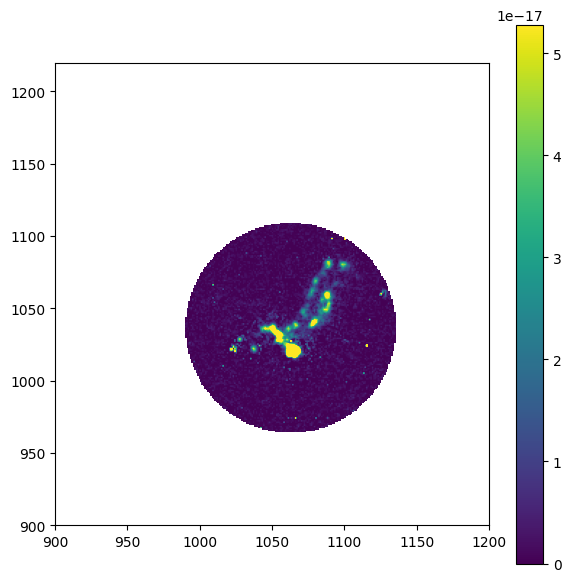

In [10]:
flux = orb.utils.io.read_fits('//Users/leianydeoleo/Desktop/IIZW96/MAPS(SN3. Velocity10760,sigma20)/IIZw96_SN3.LineMaps.map.6548.1x1.flux.fits') #Halpha flux
graph.imshow(flux)
pl.xlim(900, 1200)
pl.ylim(900, 1220)
pl.colorbar()

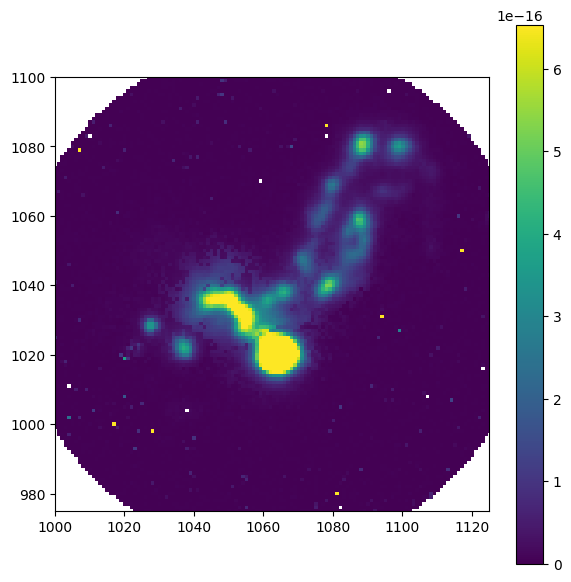

In [4]:
flux = orb.utils.io.read_fits('//Users/leianydeoleo/Desktop/IIZW96/MAPS(SN3. Velocity10760,sigma20)/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits') #Halpha flux
graph.imshow(flux)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()

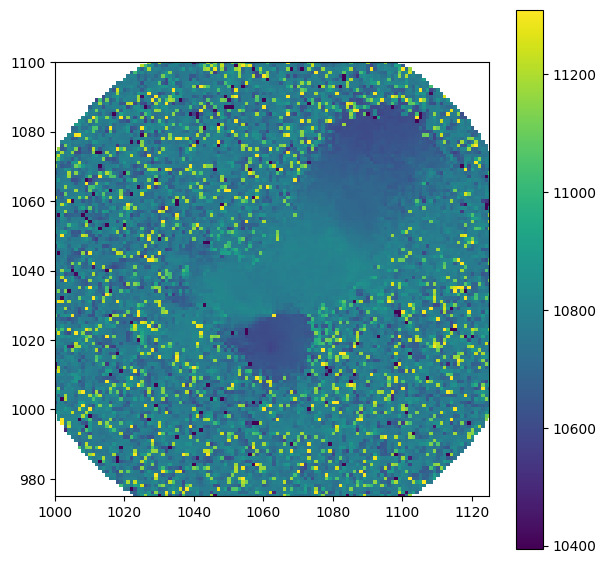

In [34]:
sigma =  orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/MAPS(SN3. Velocity10760,sigma20)/IIZw96_SN3.LineMaps.map.6548.1x1.velocity.fits')
graph.imshow(sigma)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()

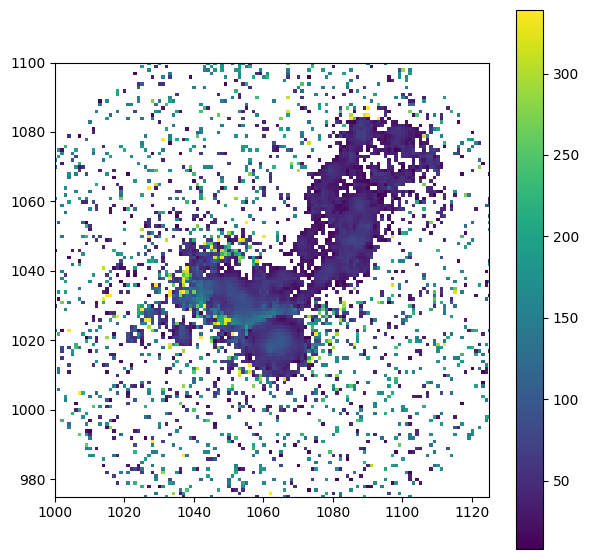

In [16]:
sigma =  orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/MAPS(SN3. Velocity10760,sigma20)/IIZw96_SN3.LineMaps.map.6583.1x1.sigma.fits')
graph.imshow(sigma)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()


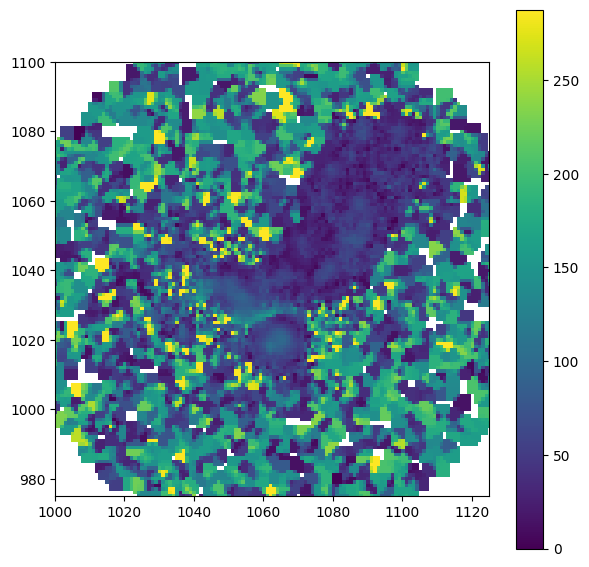

In [17]:
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.convolution import interpolate_replace_nans

broadening_map_SN3 = sigma
kernel = Gaussian2DKernel(x_stddev=0.5)  # adjust sigma
smoothed_broadening_map_SN3 = interpolate_replace_nans(broadening_map_SN3, kernel)
graph.imshow(smoothed_broadening_map_SN3)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()

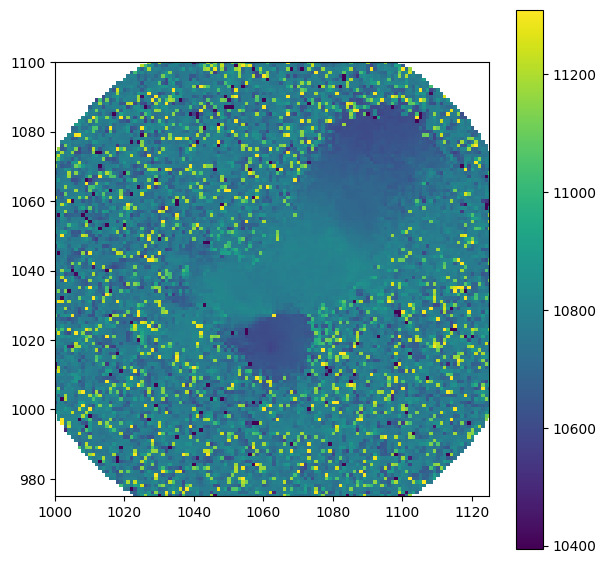

In [33]:
velocity =  orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/MAPS(SN3. Velocity10760,sigma20)/IIZw96_SN3.LineMaps.map.6583.1x1.velocity.fits')
graph.imshow(velocity)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()

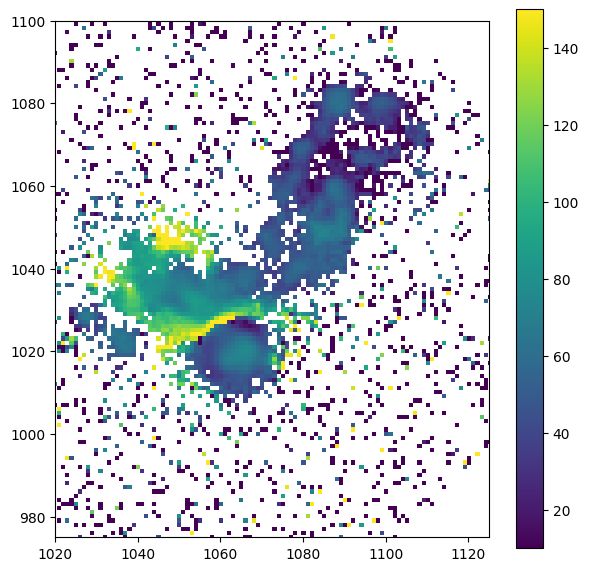

In [11]:
graph.imshow(sigma)
pl.xlim(1020, 1125)
pl.ylim(975, 1100)
pl.clim(10,150)
pl.colorbar()

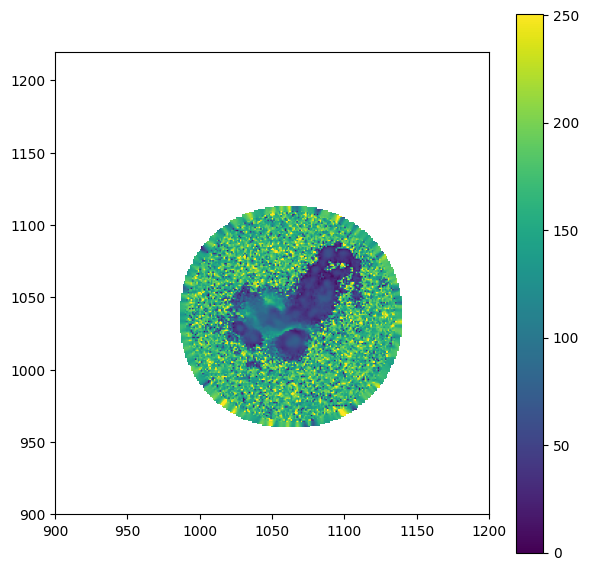

In [82]:
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.convolution import interpolate_replace_nans

broadening_map_SN3 = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits') 
kernel = Gaussian2DKernel(x_stddev=1.0)  # adjust sigma
smoothed_broadening_map_SN3 = interpolate_replace_nans(broadening_map_SN3, kernel)
graph.imshow(smoothed_broadening_map_SN3)
pl.xlim(900, 1200)
pl.ylim(900, 1220)
pl.colorbar()

In [10]:
amp_ratio = cube_SN3.get_amp_ratio_from_flux_ratio('[NII]6583', '[NII]6548', 3)
amp_ratio

2.967824020860382

In [28]:
new_vel = 89 # km/s
fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','1','1'],
pos_cov = [10660],
sigma_def=['1','1','1'],
sigma_cov = [15],
fwhm_def='fixed',
amp_def=['1', '2', '1'],
amp_guess=[1, 1, amp_ratio],
nofilter=True, binning=1)

unknown|INFO| creating output file for 20 parameters x 3 lines (1.01449728 Go)
unknown|INFO|  > allocating: height
unknown|INFO|  > allocating: height-err
unknown|INFO|  > allocating: amplitude
unknown|INFO|  > allocating: amplitude-err
unknown|INFO|  > allocating: velocity
unknown|INFO|  > allocating: velocity-err
unknown|INFO|  > allocating: fwhm
unknown|INFO|  > allocating: fwhm-err
unknown|INFO|  > allocating: sigma
unknown|INFO|  > allocating: sigma-err
unknown|INFO|  > allocating: flux
unknown|INFO|  > allocating: flux-err
unknown|INFO|  > allocating: logGBF
unknown|INFO|  > allocating: chi2
unknown|INFO|  > allocating: rchi2
unknown|INFO|  > allocating: ks_pvalue
unknown|INFO|  > allocating: cont_p0
unknown|INFO|  > allocating: cont_p1
unknown|INFO|  > allocating: cont_p2
unknown|INFO|  > allocating: cont_p3
unknown|INFO| Number of spectra to fit: 25579
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py:166: RuntimeWarning: invalid value encounte

 [==========] [100%] [completed in 0.118 s]                                   


unknown|INFO| fitting started at 2025-11-10 16:31:23.047067
unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : ['pos_cov_0', 'pos_cov_1']
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|INFO| 180 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [          ] [4%] [nans/pix|nanh] [33.5 s|26.4 s]                            

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 870, in curve_fit
    res = least_squares(func, p0, jac=jac, bounds=bounds, method=method,
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_lsq/least_squares.py", line 818, in least_squares
    raise ValueError("`x0` is infeasible.")
ValueError: `x0` is infeasible.

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in

...

 File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
KeyboardInterrupt
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rl

/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 870, in curve_fit
    res = least_squares(func, p0, jac=jac, bounds=bounds, method=method,
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_lsq/least_squares.py", line 818, in least_squares
    raise ValueError("`x0` is infeasible.")
ValueError: `x0` is infeasible.

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python

t/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364,

_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 870, in curve_fit
    res = least_squares(func, p0, jac=jac, bounds=bounds, method=method,
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_lsq/least_squares.py", line 818, in least_squares
    raise ValueError("`x0` is infeasible.")
ValueError: `x0` is infeasible.

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
   

ask = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
KeyboardInterrupt
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
Process ForkServerPool

In [28]:
new_vel = 80 # km/s
fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','2','2'],
pos_cov_map = [vel_map,vel_map],
sigma_def=['1','2','2'],
sigma_cov = [45,45],
fwhm_def='fixed',
amp_def=['1', '2', '1'],
amp_guess=[1, 1, amp_ratio],
nofilter=True, binning=1)

unknown|INFO| creating output file for 20 parameters x 3 lines (1.01449728 Go)
unknown|INFO|  > allocating: height
unknown|INFO|  > allocating: height-err
unknown|INFO|  > allocating: amplitude
unknown|INFO|  > allocating: amplitude-err
unknown|INFO|  > allocating: velocity
unknown|INFO|  > allocating: velocity-err
unknown|INFO|  > allocating: fwhm
unknown|INFO|  > allocating: fwhm-err
unknown|INFO|  > allocating: sigma
unknown|INFO|  > allocating: sigma-err
unknown|INFO|  > allocating: flux
unknown|INFO|  > allocating: flux-err
unknown|INFO|  > allocating: logGBF
unknown|INFO|  > allocating: chi2
unknown|INFO|  > allocating: rchi2
unknown|INFO|  > allocating: ks_pvalue
unknown|INFO|  > allocating: cont_p0
unknown|INFO|  > allocating: cont_p1
unknown|INFO|  > allocating: cont_p2
unknown|INFO|  > allocating: cont_p3
unknown|INFO| Number of spectra to fit: 25579
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orcs/core.py:166: RuntimeWarning: invalid value encounte

 [==========] [100%] [completed in 0.118 s]                                   


unknown|INFO| fitting started at 2025-11-10 16:31:23.047067
unknown|INFO| Init of the parallel processing server with 8 threads
unknown|INFO| passed mapped kwargs : ['pos_cov_0', 'pos_cov_1']
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/utils/image.py:1120: RuntimeWarning: Mean of empty slice
  return np.squeeze(np.nanmean(np.nanmean(im_view, axis=3), axis=1))

unknown|INFO| 180 rows to fit
unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



 [          ] [4%] [nans/pix|nanh] [33.5 s|26.4 s]                            

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 870, in curve_fit
    res = least_squares(func, p0, jac=jac, bounds=bounds, method=method,
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_lsq/least_squares.py", line 818, in least_squares
    raise ValueError("`x0` is infeasible.")
ValueError: `x0` is infeasible.

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in

...

 File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
KeyboardInterrupt
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rl

/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 870, in curve_fit
    res = least_squares(func, p0, jac=jac, bounds=bounds, method=method,
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_lsq/least_squares.py", line 818, in least_squares
    raise ValueError("`x0` is infeasible.")
ValueError: `x0` is infeasible.

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python

t/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364,

_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
    fit_results = scipy.optimize.curve_fit(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py", line 870, in curve_fit
    res = least_squares(func, p0, jac=jac, bounds=bounds, method=method,
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/scipy/optimize/_lsq/least_squares.py", line 818, in least_squares
    raise ValueError("`x0` is infeasible.")
ValueError: `x0` is infeasible.

Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fft.py", line 884, in prepared_fit
    _fit = orb.fit._fit_lines_in_spectrum(
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 2680, in _fit_lines_in_spectrum
    fit = fv.fit(compute_mcmc_error=compute_mcmc_error)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/fit.py", line 457, in fit
   

ask = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
KeyboardInterrupt
Traceback (most recent call last):
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/opt/anaconda3/envs/orb3/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
Process ForkServerPool

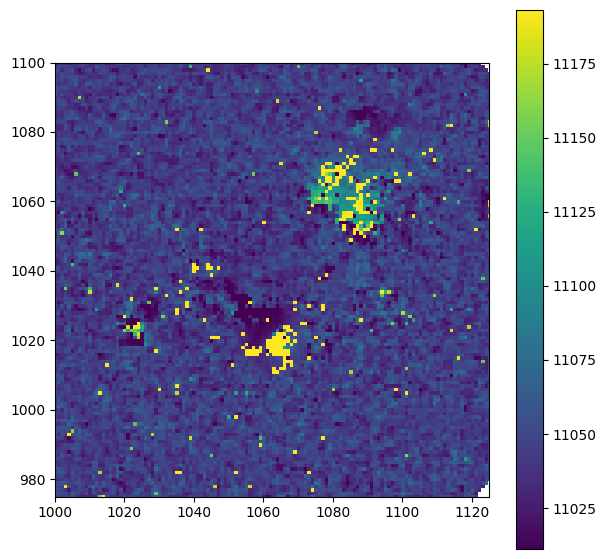

In [32]:
sigma =  orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.velocity.fits')
graph.imshow(sigma)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()

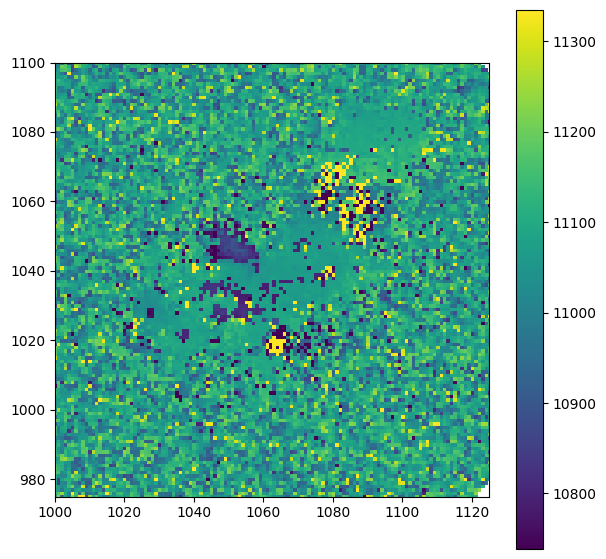

In [22]:
sigma =  orb.utils.io.read_fits('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.velocity.fits')
graph.imshow(sigma)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()

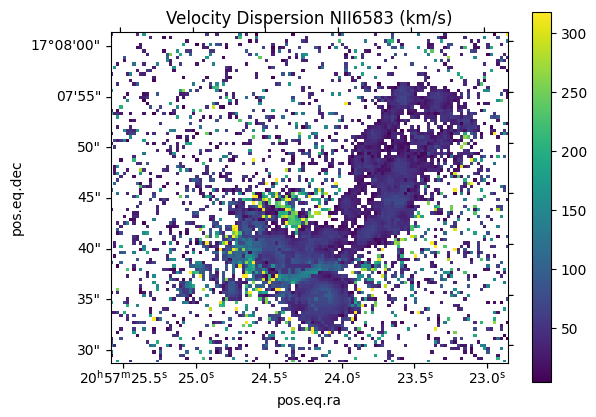

In [29]:
def show_map(path, title):
    fig = pl.figure()
    ax = fig.add_subplot(111, projection=cube_SN3.get_wcs())
    ax.coords[0].set_major_formatter('hh:mm:ss.s')
    ax.coords[1].set_major_formatter('dd:mm:ss')
    _map = orb.utils.io.read_fits(path).T
    pl.imshow(_map, origin='lower',
              vmin=np.nanpercentile(_map, 1),
              vmax=np.nanpercentile(_map, 99))
    pl.xlim(1000, 1120)
    pl.ylim(1000, 1100)
    pl.title(title)
    pl.colorbar()


show_map('/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.sigma.fits' , r'Velocity Dispersion NII6583 (km/s)')
plt.savefig("/Users/leianydeoleo/Desktop/IIZw96/sigma_NII6583.png", bbox_inches="tight")  

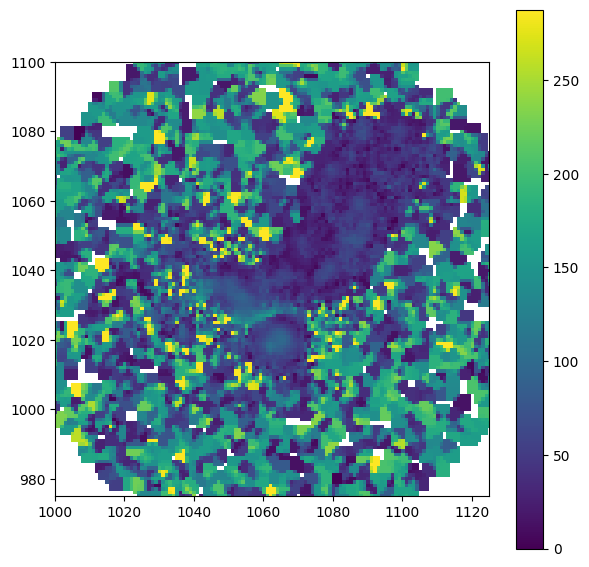

In [15]:
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.convolution import interpolate_replace_nans

broadening_map_SN3 = sigma
kernel = Gaussian2DKernel(x_stddev=0.5)  # adjust sigma
smoothed_broadening_map_SN3 = interpolate_replace_nans(broadening_map_SN3, kernel)
graph.imshow(smoothed_broadening_map_SN3)
pl.xlim(1000, 1125)
pl.ylim(975, 1100)
pl.colorbar()

In [129]:
from astropy.io import fits

# Load FITS header manually
with fits.open('/Users/leianydeoleo/Desktop/IIZw96/SN3.fits') as hdul:
    header = hdul[0].header

# Extract spectral WCS from header (typically axis 3 for SITELLE)
crpix3 = header['CRPIX3']   # reference pixel
crval3 = header['CRVAL3']   # wavelength at reference pixel (in Å)
cdelt3 = header['CDELT3']   # wavelength step per pixel (in Å)

# Define redshift and rest-frame line wavelengths
z_sys = 0.0369
rest_waves = {
    'Halpha': 6562.8,
    '[NII]6548': 6548.05,
    '[NII]6583': 6583.45
}

# Convert rest to observed wavelengths
obs_waves = {line: lam * (1 + z_sys) for line, lam in rest_waves.items()}

# Convert observed λ to spectral channel (cube position)
def wave_to_channel(wave_obs):
    return (wave_obs - crval3) / cdelt3 + crpix3

pos_cov = [wave_to_channel(obs_waves[line]) for line in rest_waves]
print("Fitting start positions (cube channels):", pos_cov)

init_sigma = 15 
new_vel = 85

amp_ratio = cube.get_amp_ratio_from_flux_ratio('[NII]6583', '[NII]6548', 3)
amp_ratio

fit = cube_SN3.fit_lines_in_region('/Users/leianydeoleo/Desktop/IIZw96/region5.reg',
('Halpha','[NII]6548' ,'[NII]6583', ),
fmodel='sincgauss',
pos_def=['1','2','3'],
pos_cov = [pos_cov, pos_cov],
sigma_def=['1','2','3'],
sigma_cov =[init_sigma]*3, [init_sigma]*3, 
amp_cov=[1.0, 0.33, 1.0],     
amp_guess=[1, 1, amp_ratio],
nofilter=True,
binning=1)

   
                                   



SyntaxError: positional argument follows keyword argument (4207907875.py, line 46)